<a href="https://colab.research.google.com/github/sergeyarefjev/study/blob/main/ml/wb_timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install optuna

In [ ]:
%reset -f

In [ ]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL, MSTL

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import BaseEstimator, TransformerMixin

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import xgboost as xgb

#import optuna

import gc

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

# Модифицируйте в соответствии со своей задачей
TRACK = "solo"  # "solo" or "team"
TRAIN_DAYS = 7
MAX_TRAIN_ROWS = 1_500_000
RIDGE_ALPHA = 10.0
RANDOM_STATE = 42

# Меняйте конфигурацию при необходимости
TRACK_CONFIG = {
    "solo": {
        "train_path": "/content/drive/MyDrive/ML_data/wb_hakaton/train_solo_track.parquet",
        "test_path": "/content/drive/MyDrive/ML_data/wb_hakaton/test_solo_track.parquet",
        "target_col": "target_1h",
        "forecast_points": 8,
    },
    "team": {
        "train_path": "train_team_track.parquet",
        "test_path": "test_team_track.parquet",
        "target_col": "target_2h",
        "forecast_points": 10,
    },
}

CONFIG = TRACK_CONFIG[TRACK]
TARGET_COL = CONFIG["target_col"]
FORECAST_POINTS = CONFIG["forecast_points"]
FUTURE_TARGET_COLS = [f"target_step_{step}" for step in range(1, FORECAST_POINTS + 1)]
STATUS_COL = [f"status_{number}" for number in range(1, 7)]

##GBM

In [ ]:
class GradPredict:
    def __init__(self,
                  n_lags=1,
                  n_estimators=None,
                  max_depth=None,
                  learning_rate=None,
                  reg_alpha=None,
                  reg_lambda=None,
                  subsample=1,
                  colsample_bytree=1,
                 detrend=False,
                 smooth=False,
                 frac_smooth=0.05,
                 alignment=False):
        self.n_lags = n_lags
        self.detrend = detrend
        self.smooth = smooth
        self.alignment = alignment
        self.frac_smooth = frac_smooth
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu').type
        self.params = {
            "n_estimators" : n_estimators,
            "max_depth" : max_depth,
            "learning_rate" : learning_rate,
            "reg_alpha" : reg_alpha,
            "reg_lambda" : reg_lambda,
            "subsample" : subsample,
            "colsample_bytree" : colsample_bytree,
            "tree_method" : "hist",
            "device" : self.device
        }


    def create_trajectory_matrix(self, X):
        """
        input:
        X - np.array (len_series, count_components)

        output:
        X_expand - np.array (len_series - n_lags, n_lags * count_components)
        """
        X_expand = np.zeros((X.shape[0]- self.n_lags, self.n_lags * self.n_components))
        for i in range(1, self.n_lags + 1):
            j = (i - 1) * self.n_components
            X_expand[:, j:j + self.n_components] = X[self.n_lags - i:X.shape[0] - i, :]
        return X_expand

    #Подумать над названием
    def create_point_learn(self, x):
        """
        input:
        x - np.array (len_series, count_components)

        output:
        x_expand - np.array (1, count_components)
        """
        x_expand = np.zeros((1, self.n_components * self.n_lags))
        for i in range(self.n_lags):
            j = i * self.n_components
            x_expand[:, j:j + self.n_components] = x[x.shape[0] - i - 1, :]
        return x_expand

    def detrending(self, y_train):
        self.a, self.b = np.zeros((1, self.n_components)), np.zeros((self.length, self.n_components))
        time = np.arange(self.length)
        a_current, b_current = np.polyfit(time, y_train, deg=1)

        self.a[0, :] = a_current.T
        self.b[:] = b_current.T

        y_train_linear = time.reshape(self.length, 1) @ self.a + self.b
        y_train = y_train - y_train_linear
        return y_train

    def smooth_series(self, X, frac):
        """
        input:
        X - np.array (length_series, n_components)
        frac - float [this frac use for all components] or np.array, list [fracs using for each components] (n_components, )

        output:
        X_smooth np.array (length_series, n_components) - smoothing X
        """
        if isinstance(frac, float):
            frac = [frac for _ in range(X.shape[1])]

        X_smooth = np.zeros_like(X)
        for i in range(X.shape[1]):
            X_smooth[:, i] = lowess(X[:, i], np.arange(X.shape[0]), frac=frac[i], return_sorted=False)
        return X_smooth

    def alignment_series(self, X):
        """
        X - np.array (length_series, n_components)
        """
        last_points = X[-1, :]
        first_points = X[0, :]
        self.a_alignment = (last_points.reshape(1, X.shape[1]) - first_points.reshape(1, X.shape[1])) / X.shape[0]
        self.b_alignment = first_points.reshape(1, X.shape[1])
        time = np.arange(X.shape[0]).reshape(X.shape[0], 1)
        X_alignment = X - (time @ self.a_alignment + self.b_alignment)
        return X_alignment

    def fit(self, X):
        """
        X - np.array size of (len_series, count_components)
        """
        if self.smooth:
            self.y_train = self.smooth_series(X, frac=self.frac_smooth)
        if self.alignment:
            self.y_train = self.alignment_series(X)
        if not self.smooth and not self.alignment:
            self.y_train = X

        self.length = X.shape[0]
        self.n_components = self.y_train.shape[1]
        self.models = [xgb.XGBRegressor(**self.params) for _ in range(X.shape[1])]

        if self.detrend:
            self.y_train = self.detrending(self.y_train)

        self.X_expand = self.create_trajectory_matrix(self.y_train)

        for i in range(X.shape[1]):
            self.models[i].fit(self.X_expand, self.y_train[self.n_lags:, i])
        return self

    def add_trend(self, pred, n_points, a, b):
        time_predict = np.arange(self.length, self.length + n_points).reshape(-1, 1)
        pred += time_predict @ a + b
        return pred


    def predict(self, n_points):

        predict = np.zeros((n_points, self.n_components))
        for j in range(n_points):
            predict_one_points = np.zeros((1, self.n_components))
            x_expand_one_points = self.create_point_learn(self.y_train)[-1:]

            for i in range(self.n_components):
                predict_one_points[0, i] = self.models[i].predict(x_expand_one_points)

            predict[j, :] = predict_one_points
            self.y_train = np.concatenate([self.y_train, predict_one_points], axis=0)

        if self.detrend:
            predict = self.add_trend(predict, n_points, self.a, self.b[:len(predict)])

        if self.alignment:
            predict = self.add_trend(predict, n_points, self.a_alignment, self.b_alignment)

        return predict


##GRU

In [ ]:
class GRUTime(nn.Module):
    def __init__(self, pred_length, n_components, hidden_size=128, num_layers=2, dropout=0.1, batch_size=64):
        super(GRUTime, self).__init__()

        self.n_components = n_components
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.batch_size = batch_size

        self.pred_length = pred_length

        self.gru = nn.GRU(
            input_size=n_components,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False
        )

        self.mlp = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_components * pred_length)
        )

    def forward(self, x):
        batch_size = x.size(0)

        h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        out, _ = self.gru(x, h_0)
        out = out[:, -1, :]
        out = self.mlp(out)

        out = out.view(batch_size, self.pred_length, self.n_components)
        return out

class WorkwithModel:
    def __init__(self, pred_length, n_components, hidden_size=128, num_layers=2, seq_length=24,
                 dropout=0.1, batch_size=64, learning_rate=3e-4, weight_decay=1e-5, verbose=True, train_ratio=0.9):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = GRUTime(pred_length, n_components, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout, batch_size=batch_size).to(self.device)
        self.criterion = nn.MSELoss()
        self.optimizer = optim.AdamW(self.model.parameters(), lr=learning_rate,
                                   weight_decay=weight_decay)

        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3
        )
        self.verbose = verbose
        self.pred_length = pred_length
        self.batch_size = batch_size
        self.seq_length = seq_length
        self.train_ratio = train_ratio
        self.n_components = n_components

    def prepare_data(self, X):
        sequences = []
        targets = []
        sequences_by_predict = []

        for i in range(len(X) - self.seq_length - self.pred_length):
            sequences.append(X[i:i + self.seq_length])
            targets.append(X[i + self.seq_length:i + self.seq_length + self.pred_length])

        for i in range(len(X) - self.seq_length - 1, len(X) - self.seq_length - self.pred_length, -1):
            sequences_by_predict.append(X[i:i + self.seq_length])

        sequences = np.array(sequences)
        targets = np.array(targets)
        sequences_by_predict = np.array(sequences_by_predict)

        n_train = int(len(X) * self.train_ratio)

        X_train_np = sequences[:n_train]
        Y_train_np = targets[:n_train]

        X_val_np = sequences[n_train:]
        Y_val_np = targets[n_train:]

        self.X_train = torch.FloatTensor(X_train_np).to(self.device)
        self.X_val = torch.FloatTensor(X_val_np).to(self.device)
        self.Y_train = torch.FloatTensor(Y_train_np).to(self.device)
        self.Y_val = torch.FloatTensor(Y_val_np).to(self.device)
        self.last_seq = torch.FloatTensor(X[-self.seq_length:]).to(self.device)
        self.sequences_by_predict = torch.FloatTensor(sequences_by_predict).to(self.device)
        return X_train_np, X_val_np, Y_train_np, Y_val_np

    def train_model(self, X, n_epochs):
        self.prepare_data(X)
        train_dataset = TensorDataset(self.X_train, self.Y_train)
        val_dataset = TensorDataset(self.X_val, self.Y_val)
        train_loader = DataLoader(train_dataset, self.batch_size, shuffle=False)
        val_loader = DataLoader(val_dataset, self.batch_size, shuffle=False)

        train_losses = []
        val_losses = []

        print("Start learning!")
        for epoch in range(n_epochs):
            self.model.train()
            epoch_train_loss = 0

            for x_train, y_train in train_loader:
                self.optimizer.zero_grad()

                pred = self.model(x_train)
                loss = self.criterion(pred, y_train)

                loss.backward()
                self.optimizer.step()
                epoch_train_loss += loss.item()
            train_loss = epoch_train_loss / len(train_loader)
            train_losses.append(train_loss)

            self.model.eval()
            with torch.no_grad():
                val_loss = 0
                for x_val, y_val in val_loader:
                    pred_val = self.model(x_val)
                    val_loss += self.criterion(pred_val, y_val).item()
                val_losses.append(val_loss / len(val_loader))

            self.scheduler.step(val_losses[-1])
            if self.verbose:
                print(f"Epoch {epoch + 1}: Train loss: {train_losses[-1]}, Validation loss: {val_losses[-1]}")

        print("Finish learning")
        return self.model, train_losses, val_losses

    def step_to_step_predict(self, length_predict):
        last_seq = self.last_seq.reshape(1, self.seq_length, self.n_components)
        predict = last_seq.clone()
        for i in range(length_predict):
            point_pred = self.model(last_seq)[:, 0, :]
            predict[:, :-1, :] = last_seq[:, 1:, :]
            predict[:, -1, :] = point_pred
            last_seq = predict.clone()
        return predict[0, -length_predict:, :].detach().cpu().numpy()

    def all_predict(self):
        predict = self.model(self.last_seq.reshape(1, self.last_seq.shape[0], self.last_seq.shape[1])
                       ).detach().cpu().numpy()[0, :, :]
        return predict

##Transformer

In [ ]:
class TransformerTimeSeriesForecast(nn.Module):

    class PositionalEncoding(nn.Module):
        def __init__(self, emb_d_model, max_len):
            super().__init__()
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            self.pe = torch.zeros((max_len, emb_d_model)).to(self.device)
            pos = torch.tensor([i // 2 for i in range(max_len)]).unsqueeze(1)
            denominator = torch.tensor(10000**(2 * torch.arange(0, emb_d_model // 2) / emb_d_model))

            self.pe[:, 0::2] = torch.sin(pos / denominator)
            self.pe[:, 1::2] = torch.cos(pos / denominator)
            self.pe = self.pe.unsqueeze(0)


        def forward(self, x):
            x = x + self.pe[:, :x.size(1)]
            return x


    def __init__(self, emb_d_model, pred_length, input_dim,
                 nhead, num_encoder_layers, num_decoder_layers,
                 dim_feedforward, dropout, batch_size=32 ,max_len=5000):
        """
        Args:
            input_dim: количество признаков во временном ряде
            pred_length: горизонт предсказания
            emb_d_model: размерность эмбеддингов
            nhead: количество голов внимания
            num_encoder_layers: количество слоев энкодера
            num_decoder_layers: количество слоев декодера
            dim_feedforward: размерность MLP внутри блоков трансформера
        """
        super().__init__()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.emb_d_model = emb_d_model
        self.pred_length = pred_length
        self.input_dim = input_dim
        self.nhead = nhead
        self.num_encoder_layers = num_encoder_layers
        self.num_decoder_layers = num_decoder_layers
        self.dim_feedforward = dim_feedforward
        self.dropout = dropout
        self.batch_size = batch_size


        self.encoder_embendings = nn.Linear(input_dim, emb_d_model)
        self.decoder_embendings = nn.Linear(input_dim, emb_d_model)

        self.encoder_pos_encoding = self.PositionalEncoding(emb_d_model, max_len)
        self.decoder_pos_encoding = self.PositionalEncoding(emb_d_model, max_len)

        self.transformer = nn.Transformer(
            d_model=emb_d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,  # Важно: (batch, seq, features)
            activation='gelu'
        )

        self.output_layer = nn.Sequential(
            nn.Linear(emb_d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(self.dropout),
            nn.Linear(dim_feedforward, input_dim)
        )

        self.encoder_norm = nn.LayerNorm(emb_d_model)
        self.decoder_norm = nn.LayerNorm(emb_d_model)

        self.start_token = nn.Parameter(torch.randn(self.batch_size,
            self.pred_length + 1, self.emb_d_model) * 0.01).to(
                torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

        self.causal_mask = self.generate_causal_mask(pred_length)

        self._init_weights()

    #deepseek порекомендовал
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def generate_causal_mask(self, size):
        causal_mask = torch.triu(torch.ones((size, size)), diagonal=0)
        causal_mask = causal_mask.masked_fill(causal_mask==1, float("-inf"))
        return causal_mask.to(self.device)

    def step_to_step(self, source, memory, length_pred):
        batch_size_now = memory.size(0)
        device = memory.device

        decoder_input = self.start_token[:batch_size_now, -1:, :]
        all_predict = []
        for i in range(length_pred):
            current_len = decoder_input.size(1)
            decoder_input_pos = self.decoder_pos_encoding(decoder_input)
          #  print(decoder_input_pos.shape)
          #  print(memory.shape)
            decoder_output = self.transformer.decoder(
                decoder_input_pos,
                memory,
                tgt_mask=self.causal_mask[:current_len, :current_len],
                memory_mask=None
            )

            last_tocken = decoder_output[:, -1:, :]
            predict = self.output_layer(last_tocken)
            all_predict.append(predict)

            next_tocken_embending = self.decoder_embendings(predict)

            decoder_input = torch.cat([decoder_input, next_tocken_embending], dim=1)
        predictions = torch.cat(all_predict, dim=1)
        return predictions

    def forward(self, source):
        source_projection = self.encoder_embendings(source)
        source_projection_pos = self.encoder_pos_encoding(source_projection)
        source_projection_pos = self.encoder_norm(source_projection_pos)

        memory = self.transformer.encoder(source_projection_pos)

        output = self.step_to_step(source, memory, self.pred_length)
        return output

class WorkWithTransformer:
    def __init__(self, emb_d_model, pred_length, input_dim,
                 nhead, num_encoder_layers, num_decoder_layers,
                 dim_feedforward, seq_length, val_percent=0.1, batch_size=32,
                 epochs=30, verbose=True,
                 dropout=0.1, lr=1e-3, weight_decay=1e-4, max_len=5000):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = TransformerTimeSeriesForecast(emb_d_model=emb_d_model,
                                                   pred_length=pred_length,
                                                   input_dim=input_dim,
                                                   nhead=nhead,
                                                   num_encoder_layers=num_encoder_layers,
                                                   num_decoder_layers=num_decoder_layers,
                                                   dim_feedforward=dim_feedforward,
                                                   dropout=dropout,
                                                   batch_size=batch_size,
                                                   max_len=max_len).to(self.device)
        self.criterion = nn.MSELoss()
        self.optimizer = optim.AdamW(self.model.parameters(), lr=lr,
                                   weight_decay=weight_decay)

        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=2
        )

        self.seq_length = seq_length
        self.pred_length = pred_length
        self.val_percent = val_percent
        self.epochs = epochs
        self.verbose = verbose
        self.batch_size = batch_size
        # ВКЛЮЧАЕМ Flash Attention (deepseek сказал так будет быстрее, вообще хз что это за крутая такая штука (правда пока не понятно, работает или нет))
        torch.backends.cuda.enable_flash_sdp(True)
        torch.set_float32_matmul_precision('high')  # Обязательно!

    def create_seq(self, X):
        sources = []
        targets = []
        for i in range(X.shape[0] - self.seq_length - self.pred_length):
            sources.append(X[i:i+self.seq_length])
            targets.append(X[i + self.seq_length:i + self.seq_length + self.pred_length])

        sources = np.array(sources, dtype=np.float32)
        targets = np.array(targets, dtype=np.float32)

        train_idx = int((1 - self.val_percent) * sources.shape[0])

        X_train = torch.FloatTensor(sources[:train_idx])
        X_val = torch.FloatTensor(sources[train_idx:])
        Y_train = torch.FloatTensor(targets[:train_idx])
        Y_val = torch.FloatTensor(targets[train_idx:])
        self.last_seq = torch.FloatTensor(X[-self.seq_length:]).to(self.device)

        train_dataset = torch.utils.data.TensorDataset(X_train, Y_train)
        val_dataset = torch.utils.data.TensorDataset(X_val, Y_val)

        train_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=self.batch_size, shuffle=True
        )
        val_loader = torch.utils.data.DataLoader(
            val_dataset, batch_size=self.batch_size, shuffle=False
        )
        return train_loader, val_loader

    def train_model(self, X, verbose=None):
        train_losses = []
        val_losses = []
        train_loader, val_loader = self.create_seq(X)
        if verbose is None:
            verbose = self.verbose


        for epoch in range(self.epochs):
            self.model.train()
            train_loss = 0
            count_batch = 0
            for x_batch, y_batch in train_loader:
                x_batch = x_batch.to(self.device)
                y_batch = y_batch.to(self.device)
                count_batch += 1

                self.optimizer.zero_grad()
                pred = self.model(x_batch)
                loss = self.criterion(y_batch, pred)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()
                train_loss += loss.item()
            train_loss /= count_batch
            train_losses.append(train_loss)

            val_loss=0
            count_batch = 0
            self.model.eval()
            for x_batch, y_batch in val_loader:
                count_batch += 1
                x_batch, y_batch = x_batch.to(self.device), y_batch.to(self.device)
                pred = self.model(x_batch)
                val_loss += self.criterion(y_batch, pred).item()
            val_loss /= count_batch
            val_losses.append(val_loss)

            self.scheduler.step(train_loss)
            if verbose:
                print(f"Epoch: {epoch+1}\tTrain loss: {train_loss:.4f}\t"+
                f"Validation loss: {val_loss:.4f}\tlr: {self.scheduler.get_last_lr()[0]:.6f}")
        return train_losses, val_losses

    def fit(self, X, verbose=True):
        return self.train_model(X, verbose=verbose)

    def predict_from_val_data(self):
        self.last_seq = self.last_seq.reshape(1, self.last_seq.shape[0],
                        self.last_seq.shape[1])
        pred = self.model(self.last_seq).detach().cpu().numpy()[0, :, :]
        return pred

    def predict(self, X):
        last_seq = X[-self.pred_length:].reshape(1, X.shape[0], X.shape[1])
        last_seq = torch.TorchTensor(last_seq).to(self.device)
        pred = self.model(last_seq).detach().cpu().numpy()[0, :, :]
        return pred

##Feature and Target preprocessing

In [ ]:
class MultitargetTargetEncoding(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X_, y_):
        """
        X.shape = (n_samples, n_features)
        y.shape = (n_samples, n_targets)
        """
        X = np.array(X_)
        y = np.mean(y_, axis=1)
        self.encodings = list()
        for i in range(X.shape[1]):
            categories = np.unique(X[:, i])
            encoding = dict()
            for category in categories:
                encoding[category] = np.mean(np.where(X[:, i] == category, y, 0))
            self.encodings.append(encoding)
        return self

    def transform(self, X_):
        X = pd.DataFrame(X_, columns=self.cols)
        for i, col in enumerate(self.cols):
            X[col] = X[col].map(self.encodings[i]).fillna(X[col].mean())
        return X

    def get_feature_names_out(self):
        return self.cols

In [ ]:
class TrendPreprocessingFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, train_time, val_time, cols, test_time=None):
        if isinstance(train_time, pd.Series):
            start_time = train_time.iloc[0]
            self.train_time = (train_time - start_time).dt.total_seconds() / 60 / 30
            self.val_time = (val_time - start_time).dt.total_seconds() / 60 / 30
            self.test_time = (test_time - start_time).dt.total_seconds() / 60 / 30 if test_time is not None else None
            self.train_time = self.train_time.to_numpy().reshape((-1, 1))
            self.val_time = self.val_time.to_numpy().reshape((-1, 1))
            self.test_time = self.test_time.to_numpy().reshape((-1, 1)) if test_time is not None else None
        else: #В этом случае он вызывается в transform и тем самым эти массивы уже такие, какие нужны
            self.train_time = train_time
            self.val_time = val_time
            self.test_time = test_time
        self.cols = cols


    def fit(self, X, y=None):
        self.a, self.b = [], []
        for i in range(X.shape[1]):
            a_i, b_i = np.polyfit(self.train_time.reshape(-1,), X[:, i], deg=1)
            self.a.append(a_i)
            self.b.append(b_i)
        self.a = np.array(self.a).reshape((1, -1))
        self.b = np.array(self.b).reshape((1, -1))
        return self


    def transform(self, X):
        if X.shape[0] == self.train_time.shape[0]:
            X_detrend = X - (self.train_time @ self.a + self.b)
        elif X.shape[0] == self.val_time.shape[0]:
            X_detrend = X - (self.val_time @ self.a + self.b)
        else:
            X_detrend = X - (self.test_time @ self.a + self.b)
        return X_detrend


    def inverse_transform(self, X):
        if X.shape[0] == self.train_time.shape[0]:
            X_with_trand = X + (self.train_time @ self.a + self.b)
        elif X.shape[0] == self.val_time.shape[0]:
            X_with_trand = X + (self.val_time @ self.a + self.b)
        else:
            X_with_trand = X + (self.test_time @ self.a + self.b)
        return X_with_trand

    def get_feature_names_out(self, a=None):
        return self.cols

In [ ]:
class TrendPreprocessingTarget(BaseEstimator, TransformerMixin):
    def __init__(self, train_time, val_time, cols, test_time=None):
        if isinstance(train_time, pd.Series):
            start_time = train_time.iloc[0]
            self.train_time = (train_time - start_time).dt.total_seconds() / 60 / 30
            self.val_time = (val_time - start_time).dt.total_seconds() / 60 / 30
            self.test_time = (test_time - start_time).dt.total_seconds() / 60 / 30 if test_time is not None else None
            self.train_time = self.train_time.to_numpy().reshape((-1, 1))
            self.val_time = self.val_time.to_numpy().reshape((-1, 1))
            self.test_time = self.test_time.to_numpy().reshape((-1, 1)) if test_time is not None else None
        else: #В этом случае он вызывается в transform и тем самым эти массивы уже такие, какие нужны
            self.train_time = train_time
            self.val_time = val_time
            self.test_time = test_time
        self.cols = cols

    def fit(self, y):
        self.a, self.b = [], []
        for i in range(y.shape[1]):
            a_i, b_i = np.polyfit(self.train_time.reshape(-1,), y[:, i], deg=1)
            self.a.append(a_i)
            self.b.append(b_i)
        self.a = np.array(self.a).reshape((1, -1))
        self.b = np.array(self.b).reshape((1, -1))
        return self

    def transform(self, y):
        if y.shape[0] == self.train_time.shape[0]:
            y_detrend = y - (self.train_time @ self.a + self.b)
        elif y.shape[0] == self.val_time.shape[0]:
            y_detrend = y - (self.val_time @ self.a + self.b)
        else:
            y_detrend = y - (self.test_time @ self.a + self.b)
        return y_detrend


    def inverse_transform(self, y):
        if y.shape[0] == self.train_time.shape[0]:
            y_with_trand = y + (self.train_time @ self.a + self.b)
        elif y.shape[0] == self.val_time.shape[0]:
            y_with_trand = y + (self.val_time @ self.a + self.b)
        else:
            y_with_trand = y + (self.test_time @ self.a + self.b)
        return y_with_trand

    def get_feature_names_out(self, a=None):
        return self.cols

## Загрузка данных


In [ ]:
train_df_start = pd.read_parquet(CONFIG["train_path"])
test_df = pd.read_parquet(CONFIG["test_path"])

train_df_start["timestamp"] = pd.to_datetime(train_df_start["timestamp"])
test_df["timestamp"] = pd.to_datetime(test_df["timestamp"])

train_df_start = train_df_start.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
test_df_start = test_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)

train_df = train_df_start.sort_values(["timestamp", "route_id"]).iloc[int(0.5 * len(train_df_start)):]
train_df = train_df.sort_values(["route_id", "timestamp"]).reset_index(drop=True)
del train_df_start
gc.collect()

print("track:", TRACK)
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)


track: solo
train shape: (2315000, 9)
test shape: (8000, 3)


In [ ]:
display(train_df.head())
display(test_df.head())


,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h
0,0,2025-09-14 05:30:00,5,9,9,53219,259877,15,38880
1,0,2025-09-14 06:00:00,4,14,9,55652,256461,16,0
2,0,2025-09-14 06:30:00,6,16,22,51959,259810,16,160786
3,0,2025-09-14 07:00:00,8,12,38,48261,265333,15,391515
4,0,2025-09-14 07:30:00,16,7,2,51636,262472,15,309908


,id,route_id,timestamp
0,0,471,2025-11-01 11:00:00
1,1,471,2025-11-01 11:30:00
2,2,471,2025-11-01 12:00:00
3,3,471,2025-11-01 12:30:00
4,4,471,2025-11-01 13:00:00


In [ ]:
print("Train date range:", train_df["timestamp"].min(), "->", train_df["timestamp"].max())
print("Test date range:", test_df["timestamp"].min(), "->", test_df["timestamp"].max())
print("Train routes:", train_df["route_id"].nunique())
print("Test routes:", test_df["route_id"].nunique())


Train date range: 2025-09-14 05:30:00 -> 2025-11-01 10:30:00
Test date range: 2025-11-01 11:00:00 -> 2025-11-01 14:30:00
Train routes: 1000
Test routes: 1000


## EDA train-данных и чистка

In [ ]:
overview = pd.DataFrame(
    {
        "dtype": train_df.dtypes.astype(str),
        "missing_cnt": train_df.isna().sum(),
        "missing_pct": (train_df.isna().mean() * 100).round(4),
        "n_unique": train_df.nunique(dropna=False),
    }
)
overview


,dtype,missing_cnt,missing_pct,n_unique
route_id,int64,0,0.0,1000
timestamp,datetime64[ns],0,0.0,2315
status_1,int64,0,0.0,249
status_2,int64,0,0.0,232
status_3,int64,0,0.0,244
status_4,int64,0,0.0,292760
status_5,int64,0,0.0,1184479
status_6,int64,0,0.0,76730
target_1h,int64,0,0.0,621198


In [ ]:
status_cols = sorted([col for col in train_df.columns if col.startswith("status_")])
print("Status columns:", status_cols)
print("Target column:", TARGET_COL)
print("Forecast points:", FORECAST_POINTS)


Status columns: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6']
Target column: target_1h
Forecast points: 8


In [ ]:
q = 0.9999
window_length = 10
for col in status_cols + [TARGET_COL]:
    threshold = train_df[col].quantile(q)
    train_df.loc[train_df[col] > threshold, col] = np.nan
    train_df[col] = train_df[col].fillna(train_df[col].rolling(window=window_length, center=True).mean())
    train_df[col] = train_df[col].fillna(method='ffill').fillna(method='bfill')

/tmp/ipykernel_10093/3490122010.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df[col] = train_df[col].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_10093/3490122010.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df[col] = train_df[col].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_10093/3490122010.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df[col] = train_df[col].fillna(method='ffill').fillna(method='bfill')
/tmp/ipykernel_10093/3490122010.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df[col] = train_df[col].fillna(method='ffill').fillna(method='bfill')
/tmp

In [ ]:
train_df.isna().sum()

,0
route_id,0
timestamp,0
status_1,0
status_2,0
status_3,0
status_4,0
status_5,0
status_6,0
target_1h,0


## Картиночки

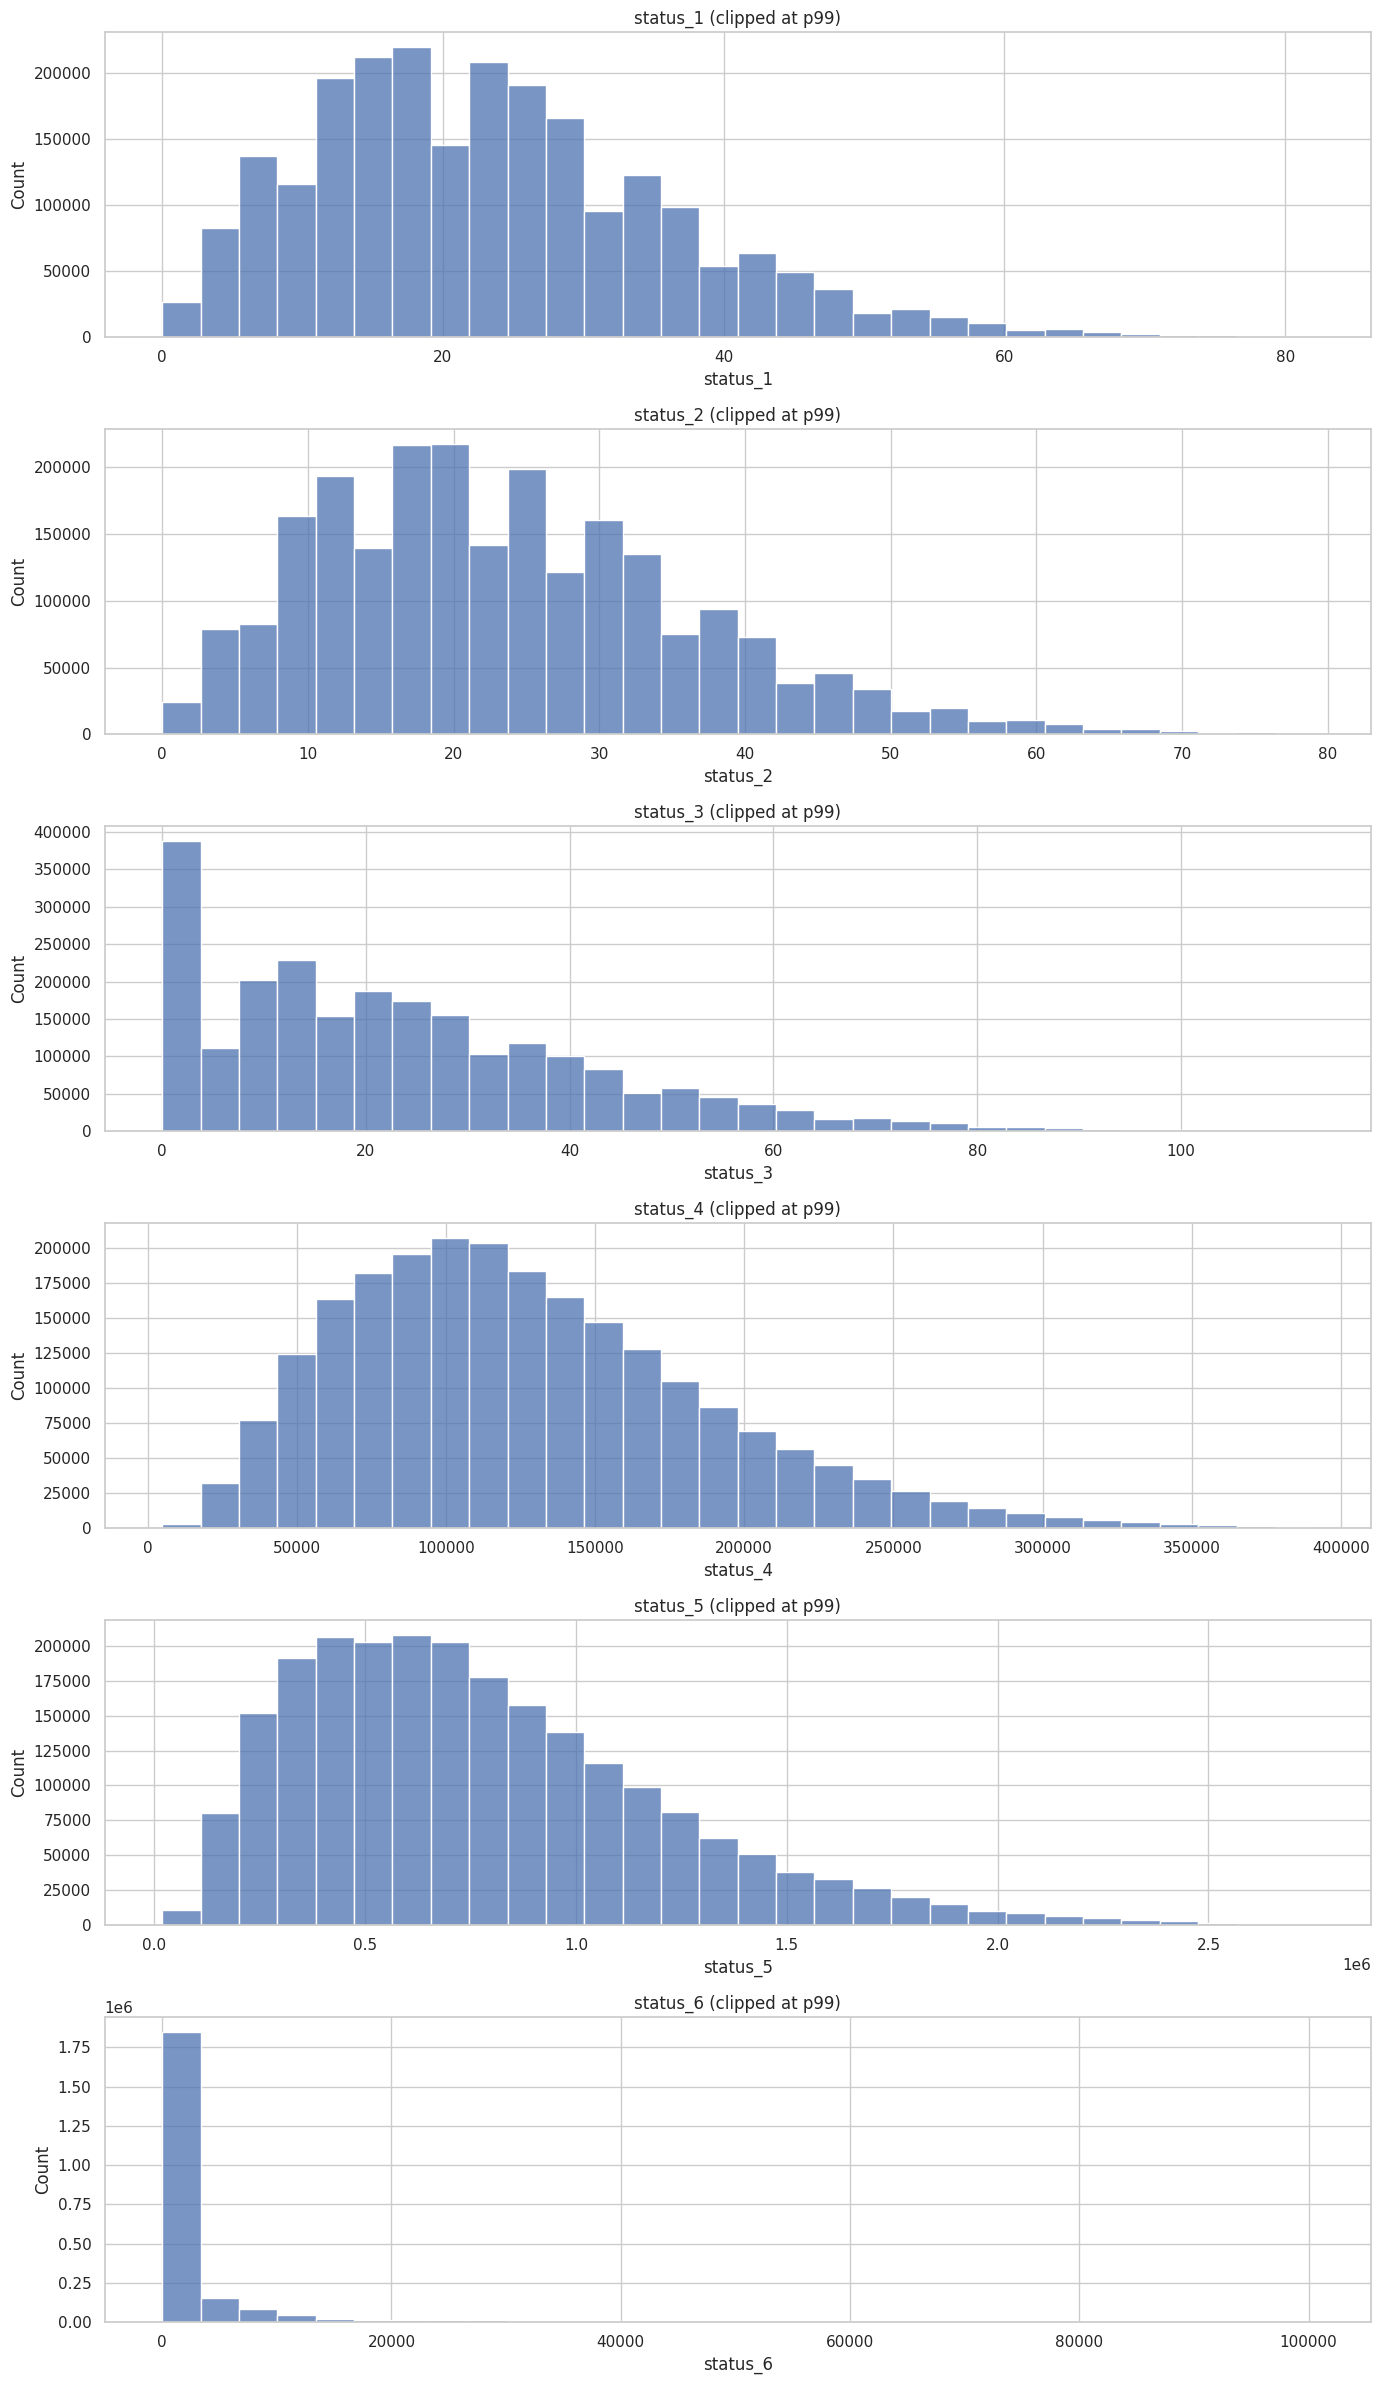

In [ ]:
fig, axes = plt.subplots(len(status_cols), 1, figsize=(14, 4 * len(status_cols)))

if len(status_cols) == 1:
    axes = [axes]

for i, col in enumerate(status_cols):
    sns.histplot(train_df[col].clip(upper=train_df[col].quantile(1)), bins=30, ax=axes[i], kde=False)
    axes[i].set_title(f"{col} (clipped at p99)")

plt.tight_layout()
plt.show()


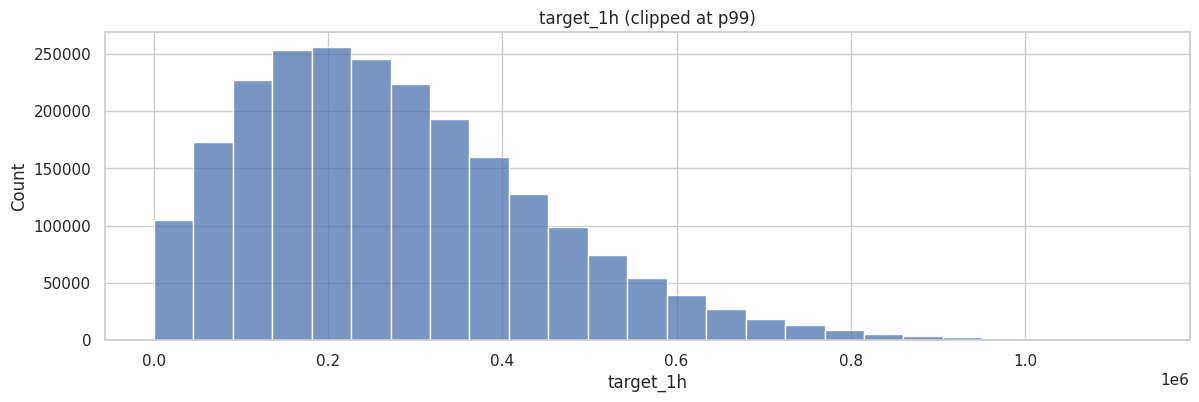

In [ ]:
plt.figure(figsize=(14, 4))
sns.histplot(train_df[TARGET_COL].clip(upper=train_df[TARGET_COL].quantile(1)), bins=25, kde=False)
plt.title(f"{TARGET_COL} (clipped at p99)")
plt.show()


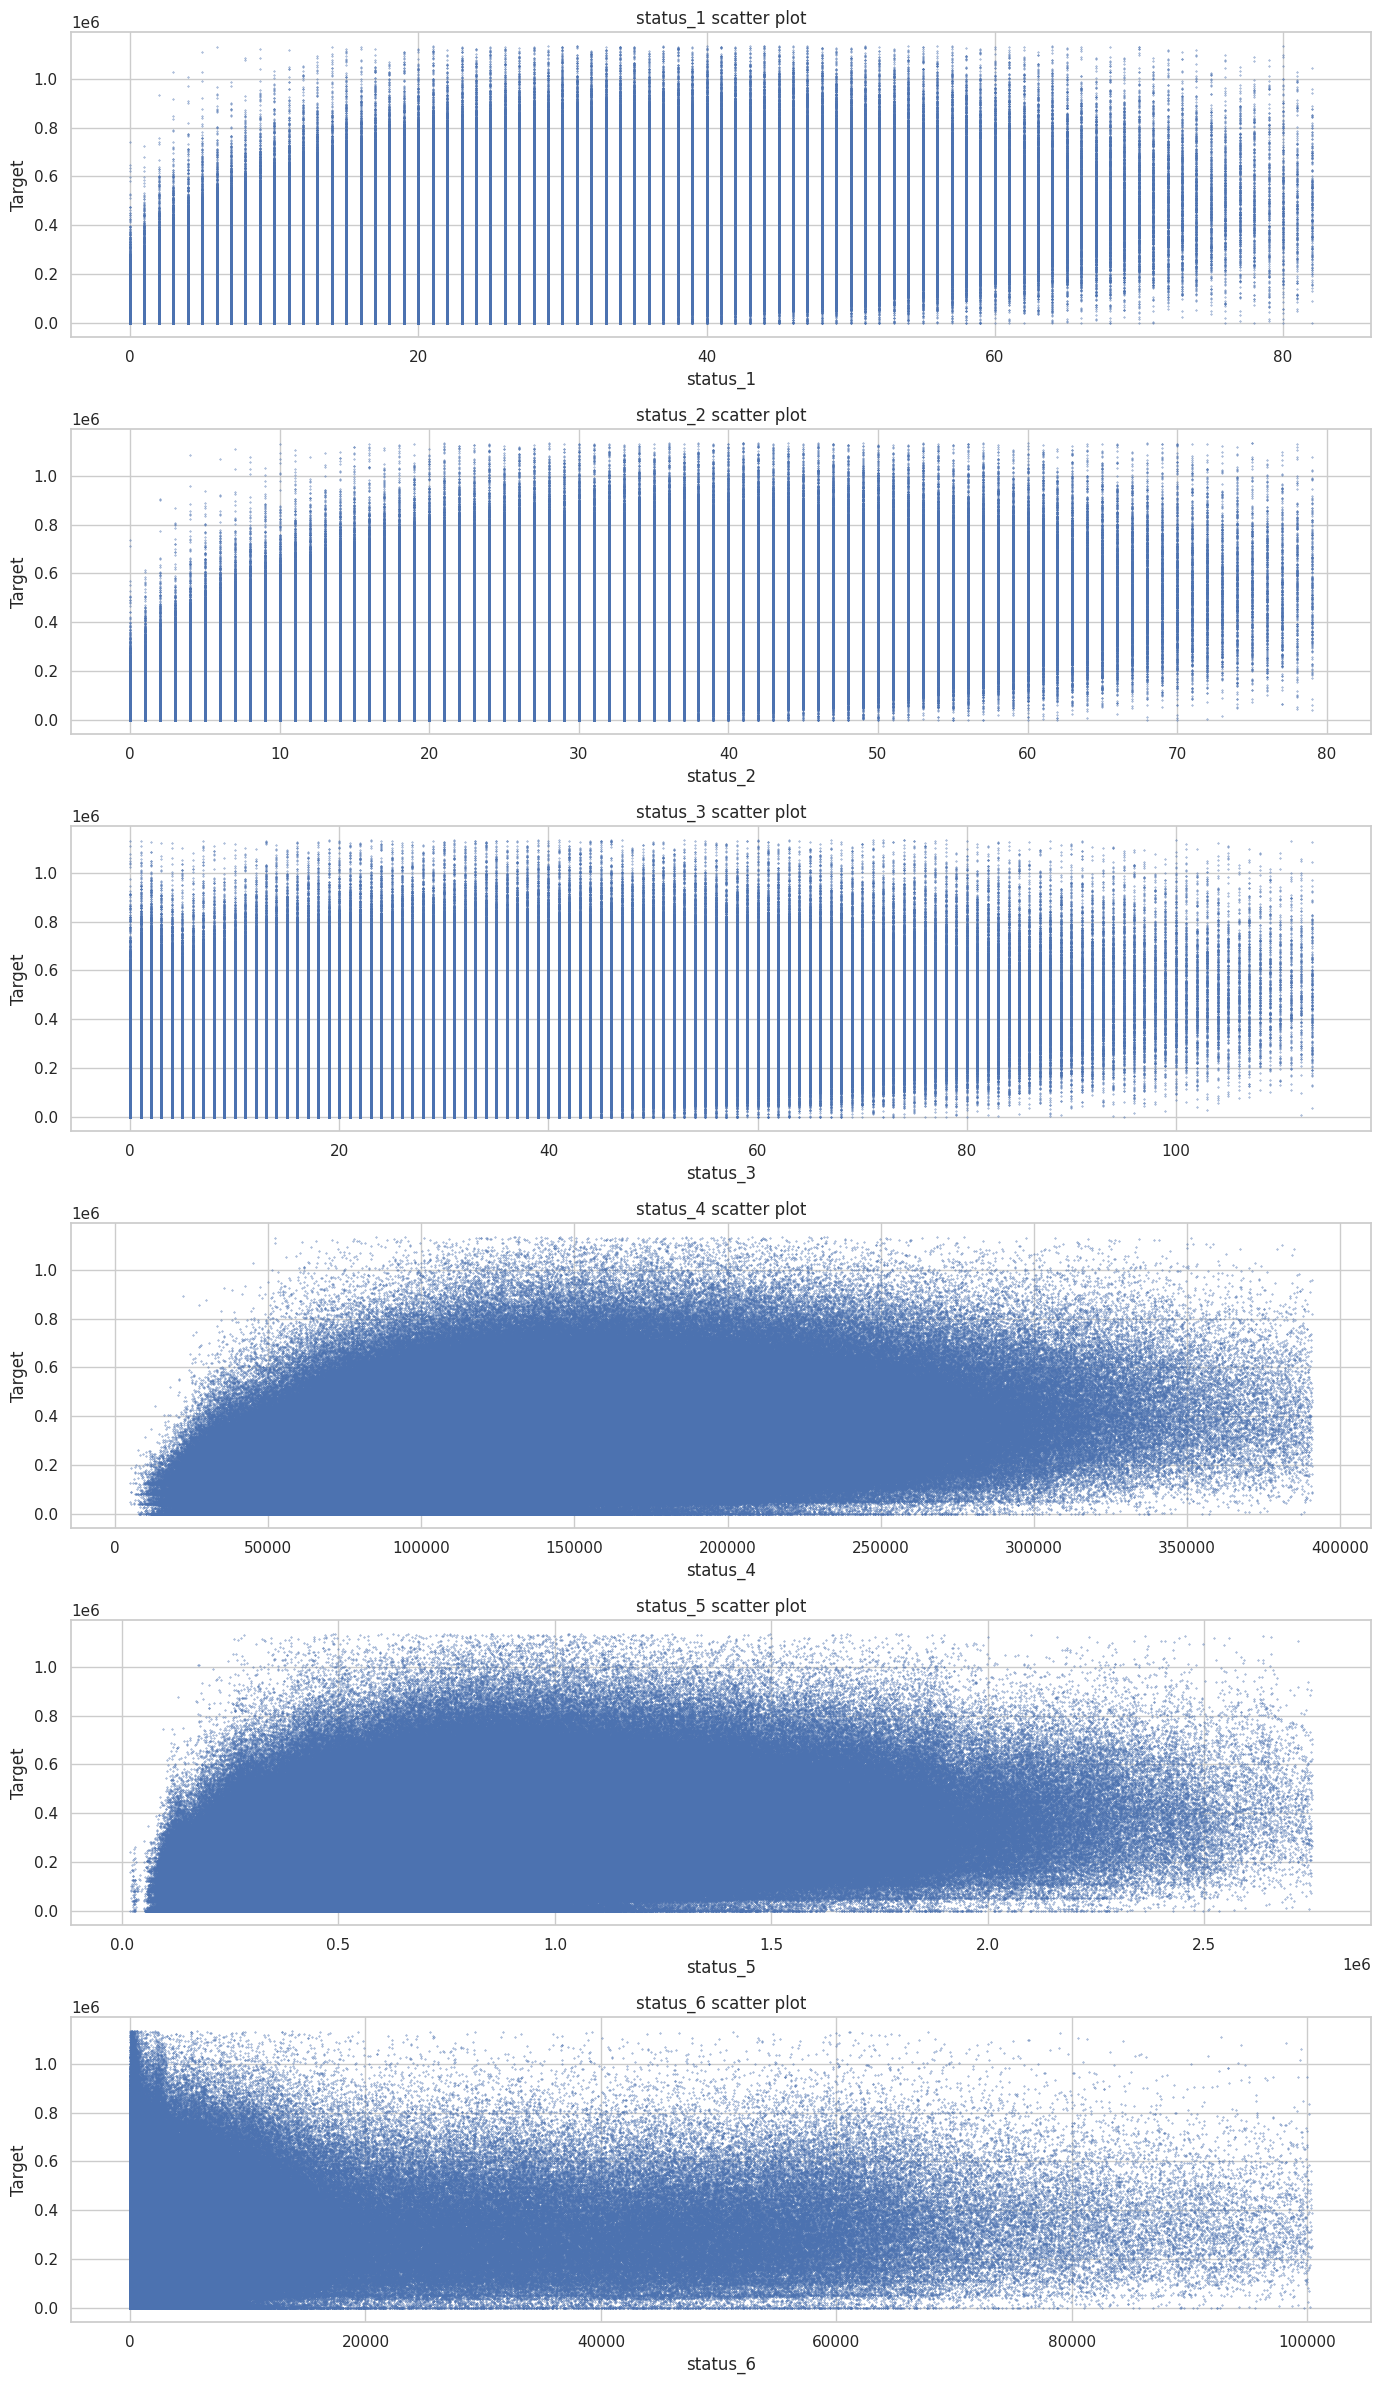

In [ ]:
fig, axes = plt.subplots(ncols=1, nrows=len(STATUS_COL), figsize=(14, 4 * len(status_cols)))
for i in range(len(STATUS_COL)):
    axes[i].scatter(train_df[STATUS_COL[i]], train_df[TARGET_COL], s=0.1)
    axes[i].set_title(f"{STATUS_COL[i]} scatter plot")
    axes[i].set_xlabel(f"{STATUS_COL[i]}")
    axes[i].set_ylabel(f"Target")

plt.tight_layout()
#Норм идеей будет попробовать поубирать все точки, которые сильно выше/правее основного скопления (проклипать данные от выбросов)

In [ ]:
idx_start = 0
idx_finish = -1
route_id = 0
x = train_df["timestamp"][train_df['route_id'] == route_id][idx_start:idx_finish]
y = train_df[TARGET_COL][train_df["route_id"] == route_id][idx_start:idx_finish]
plt.plot(x, y, 'o-', markersize=3)
adfuller(y)
#Отклоняем нулевую гипотезу (считаем, что ряд стационарный)

Проверка на стационарность

In [ ]:
for route_id in range(1000):
    y = train_df[TARGET_COL][train_df["route_id"] == route_id]
    p_value = adfuller(y)[1]
    if p_value > 0.05:
        print(f"Маршрут под номером {route_id+1} влечет нестационарный ряд")

Проверка на тренд

In [ ]:
#Для каждого маршрута
count = int((train_df["timestamp"].iloc[-1] - train_df["timestamp"].iloc[0]).total_seconds() / 60 / 30) + 1
X = np.arange(count)
count_positive = 0
count_negative = 0
for route_id in range(1000):
    y = train_df[TARGET_COL][train_df["route_id"] == route_id]
    X = sm.add_constant(X)
    model = sm.OLS(y, X)
    results = model.fit()
    right = results.conf_int().loc["x1", 0]
    left = results.conf_int().loc["x1", 1]
    if left > 0:
        count_positive += 1
    elif right < 0:
        count_negative += 1
    if route_id == 0:
        print(results.summary())
print("Количество маршрутов с положительным трендом: ", count_positive)
print("Количество маршрутов с отрицательным трендом: ", count_negative)
print("Количество маршрутов с статистически не значимым трендом: ", 1000 - count_positive - count_negative)
#Ну что могу сказать, комания развивается

                            OLS Regression Results                            
Dep. Variable:              target_1h   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     256.0
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           4.02e-56
Time:                        10:01:11   Log-Likelihood:                -58899.
No. Observations:                4630   AIC:                         1.178e+05
Df Residuals:                    4628   BIC:                         1.178e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.299e+05   2381.189     54.559      0.0

In [ ]:
#Для всего ряда в целом
count = int((train_df["timestamp"].iloc[-1] - train_df["timestamp"].iloc[0]).total_seconds() / 60 / 30) + 1
X = train_df["timestamp"]
X = (X - train_df["timestamp"].iloc[0]).dt.total_seconds() / 60 / 30
y = train_df[TARGET_COL]

X = sm.add_constant(X)
model = sm.OLS(y ,X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              target_1h   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                 6.380e+04
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:01:03   Log-Likelihood:            -6.2275e+07
No. Observations:             4630000   AIC:                         1.245e+08
Df Residuals:                 4629998   BIC:                         1.245e+08
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.271e+05    156.062   1455.228      0.0

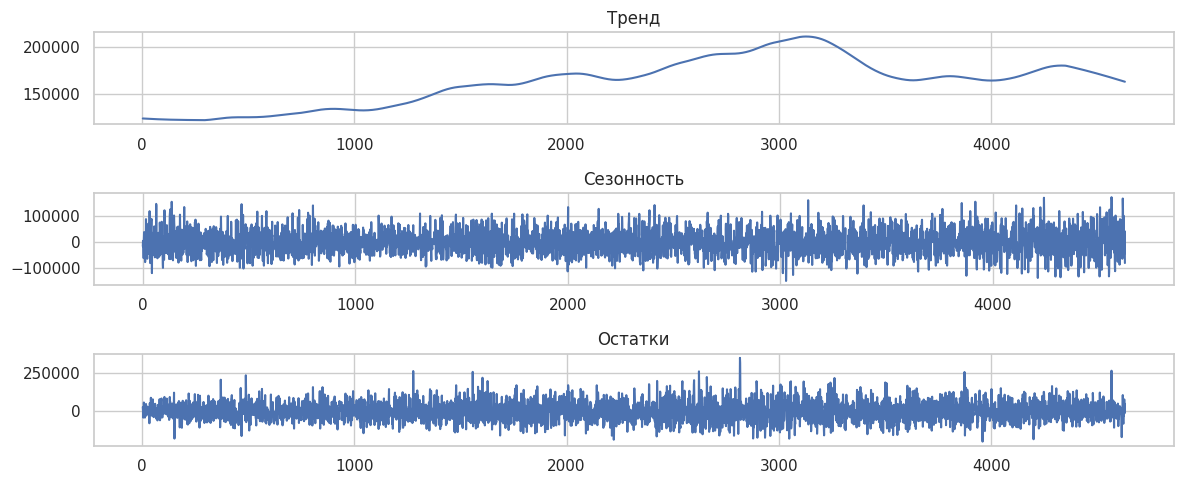

In [ ]:
route_id = 0
start_idx = 0
finish_idx = -1
y = train_df[TARGET_COL][train_df["route_id"] == route_id]
days = np.array([1, 7])
stl = MSTL(y, periods=list(map(int, 48 * days)))
result = stl.fit()
fig, ax = plt.subplots(ncols=1, nrows=3)
ax[0].plot(result.trend[start_idx:finish_idx])
ax[0].set_title("Тренд")

ax[1].plot(np.sum(result.seasonal[start_idx:finish_idx].values, axis=1))
ax[1].set_title("Сезонность")

ax[2].plot(result.resid[start_idx:finish_idx])
ax[2].set_title("Остатки")
plt.tight_layout()

##Исследование сезонности

Посмотрим на частоты, которые преобладают в ряде

1665000.0
Частоты:  [3.17974562e-08 1.56587473e-07 1.85985121e-08 7.91936645e-08
 1.73986081e-08 5.39956803e-08 1.88984881e-07 5.87952964e-08
 8.99928006e-09 1.05591553e-07 1.34989201e-07 1.21790257e-07
 6.17950564e-08 1.22990161e-07 7.67938565e-08 5.75953924e-08
 1.38588913e-07 1.26589873e-07 5.39956803e-09 1.52987761e-07
 1.54187665e-07 6.77945764e-08 1.91984641e-07 3.89968802e-08
 7.49940005e-08 5.63954884e-08 2.32181425e-07 3.77969762e-08
 1.17590593e-07 7.19942405e-09 1.93184545e-07 6.65946724e-08
 2.72378210e-07 7.31941445e-08 5.15958723e-08 5.93952484e-08
 8.57931365e-08 1.41588673e-07 1.43988481e-07 1.94384449e-07
 2.00983921e-07 3.11975042e-08 1.25989921e-08 1.40388769e-07
 1.19390449e-07 1.13990881e-07 9.89920806e-08 4.91960643e-08
 2.57979362e-08 1.22390209e-07 1.71586273e-07 1.65586753e-07
 1.54787617e-07 8.27933765e-08 2.03983681e-08 2.92176626e-07
 1.00191985e-07 8.39932805e-08 5.21958243e-08 1.80585553e-07
 5.03959683e-08 1.25389969e-07 1.39188865e-07 2.12383009e-07
 1.8

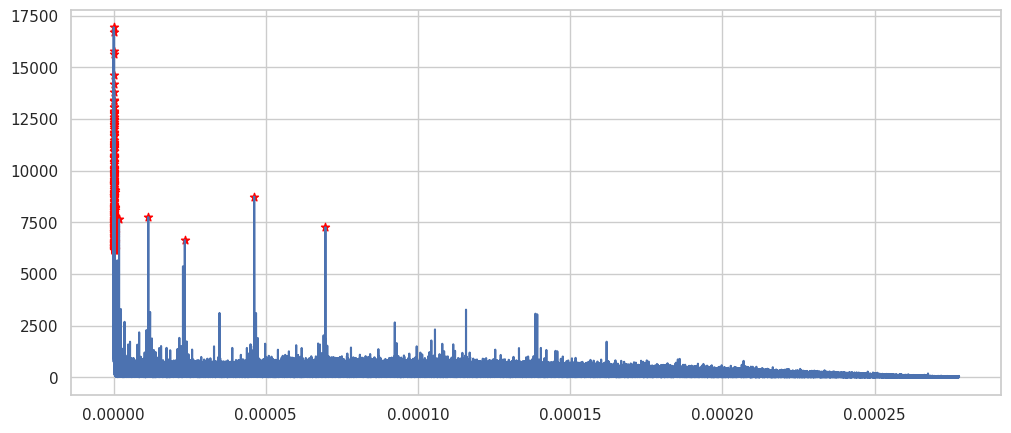

In [ ]:
signal = train_df[TARGET_COL].iloc[:]
fs = 1 / 1800 #30 минут => частота = 1 / 30 / 60

fft_vals = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(signal), 1800)

positive_freq = freqs[:len(freqs)//2]
vals = fft_vals[:len(fft_vals)//2]
amplitudes = np.abs(vals) * 2 / len(signal)
phases = np.angle(vals)

length_data_second = (train_df["timestamp"].iloc[-1]- train_df["timestamp"].iloc[0]).total_seconds()
print(length_data_second)
mask = np.where(positive_freq > 0)#1 / (14 * 24 * 3600))
positive_freq = positive_freq[mask]
amplitudes = amplitudes[mask]
phases = phases[mask]


num_freq_max = 250
max_vals_idx = np.argsort(amplitudes)[-num_freq_max:][::-1]
max_vals_amplitude = amplitudes[max_vals_idx]
max_vals_phase = phases[max_vals_idx]
max_vals_freq = positive_freq[max_vals_idx]


plt.plot(positive_freq, amplitudes)
plt.scatter(max_vals_freq, max_vals_amplitude, marker="*", color="red")
print("Частоты: ", max_vals_freq)
print("Период в днях: ", np.sort(1 / max_vals_freq / 3600 / 24))

In [ ]:
def sum_garmonics(X):
    """
    X - array shape as (length, ) or (length, 1)
    """
    X_use = X.values.reshape(-1, 1)
    result = np.sum(max_vals_amplitude * np.sin(2 * np.pi * max_vals_freq * X_use + max_vals_phase), axis=1)
    return result

In [ ]:
X = (train_df['timestamp'] - train_df["timestamp"].iloc[0]).dt.total_seconds()
#garmonics = lambda x: np.sum(max_vals_amplitude * np.sin(2 * np.pi * max_vals_freq * x + max_vals_phase))
garmonics = sum_garmonics(X)

In [ ]:
np.corrcoef([train_df[TARGET_COL], garmonics])

array([[ 1.       , -0.0103042],
       [-0.0103042,  1.       ]])

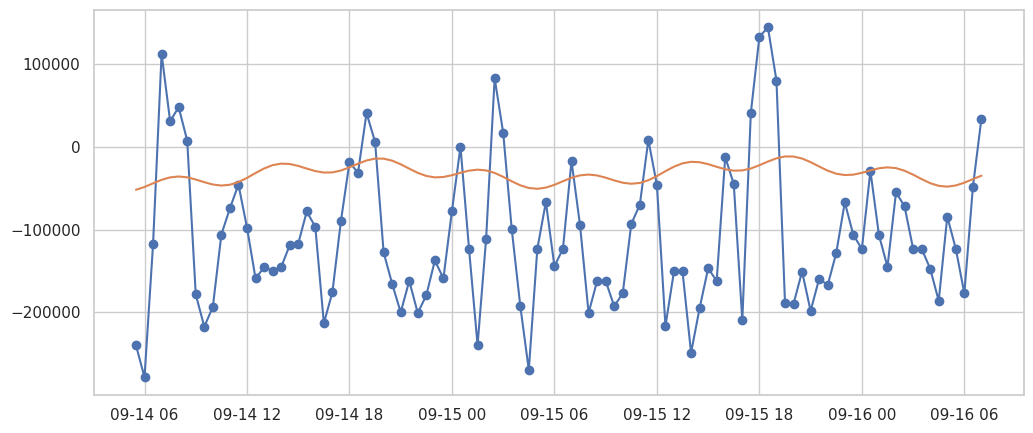

In [ ]:
start_idx = 0
finish_idx = 100
x_time = train_df["timestamp"].iloc[start_idx:finish_idx]
y_garmonics = garmonics[start_idx:finish_idx] - np.mean(garmonics)
y_true = train_df[TARGET_COL].iloc[start_idx:finish_idx] - train_df[TARGET_COL].mean()
plt.plot(x_time, y_true, "o-")
plt.plot(x_time, y_garmonics)

##Feature Engeniring

In [ ]:
ADD_COL = []
route_group = train_df.groupby("route_id", sort=False)

Добавление "запаса"

In [ ]:
#for i in range(1, len(STATUS_COL) - 1):
 #   train_df[f"add_status_{i}_{i+1}"] = train_df[f"status_{i + 1}"] - train_df[f"status_{i}"] #Некий "запас" между статусами
 #   ADD_COL.append(f"add_status_{i}_{i+1}")

Добавление "скорости"

In [ ]:
#for i in range(1, len(STATUS_COL) + 1):
 #   train_df[f"speed_status_{i}"] = route_group[f"status_{i}"].shift(0) - route_group[f"status_{i}"].shift(1)
  #  ADD_COL.append(f"speed_status_{i}")

В качестве фичи добавим день недели

In [ ]:
train_df["weekday_id"] = train_df["timestamp"].dt.weekday + 1

Добавим лаги статусов

In [ ]:
p = 36

for i in range(1, len(STATUS_COL) + 1):
    for j in range(p):
        train_df[f"status_{i}_lag_{j+1}"] = route_group[f"status_{i}"].shift(j+1)
        ADD_COL.append(f"status_{i}_lag_{j+1}")

/tmp/ipykernel_10093/3540339359.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f"status_{i}_lag_{j+1}"] = route_group[f"status_{i}"].shift(j+1)
/tmp/ipykernel_10093/3540339359.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f"status_{i}_lag_{j+1}"] = route_group[f"status_{i}"].shift(j+1)
/tmp/ipykernel_10093/3540339359.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at o

Добавим лаги предыдущих отгрузов: 5 последних

In [ ]:
p = 36

for i in range(p):
    train_df[f"taget_{i+1}_lag"] = route_group[TARGET_COL].shift(i+1)
    ADD_COL.append(f"target_{i+1}_lag")


/tmp/ipykernel_10093/4153174234.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f"taget_{i+1}_lag"] = route_group[TARGET_COL].shift(i+1)
/tmp/ipykernel_10093/4153174234.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f"taget_{i+1}_lag"] = route_group[TARGET_COL].shift(i+1)
/tmp/ipykernel_10093/4153174234.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.con

Добавим недельную сезонность

In [ ]:
point_week = 7 * 48

train_df["target_week_lag"] = route_group[TARGET_COL].shift(point_week)
ADD_COL.append("target_week_lag")

/tmp/ipykernel_10093/2837059290.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["target_week_lag"] = route_group[TARGET_COL].shift(point_week)


Добавим дневную сезонность

In [ ]:
point_day = 48

train_df["target_day_lag"] = route_group[TARGET_COL].shift(point_day)

/tmp/ipykernel_10093/556081014.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["target_day_lag"] = route_group[TARGET_COL].shift(point_day)


Добавим сезонность 4 часа (см анализ сезонности)

In [ ]:
point_day = 4 * 2

#train_df["target_4_hour"] = route_group[TARGET_COL].shift(point_day)

Добавим сезонность в 6 часов (см анализ сезонности)

In [ ]:
point_day = 6 * 2

#train_df["target_6_hour"] = route_group[TARGET_COL].shift(point_day)

Добавим месячную сезонность (см анализ сезонности)

In [ ]:
point_day = 30 * 48

train_df["target_month"] = route_group[TARGET_COL].shift(point_day)

/tmp/ipykernel_10093/620161142.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["target_month"] = route_group[TARGET_COL].shift(point_day)


In [ ]:
train_df.dropna(inplace=True)

In [ ]:
print(train_df.shape)
display(train_df.tail())

(875000, 265)


,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,target_1h,weekday_id,...,taget_30_lag,taget_31_lag,taget_32_lag,taget_33_lag,taget_34_lag,taget_35_lag,taget_36_lag,target_week_lag,target_day_lag,target_month
2314995,999,2025-11-01 08:30:00,36.0,35.0,16.0,101735.0,583961.0,285.0,13300.0,6,...,548878.0,517453.0,296633.0,402077.0,672279.0,655444.0,453929.0,155724.0,323233.0,864086.0
2314996,999,2025-11-01 09:00:00,27.0,42.0,31.0,104019.0,575723.0,291.0,122166.0,6,...,202077.0,548878.0,517453.0,296633.0,402077.0,672279.0,655444.0,77217.0,296802.0,305893.0
2314997,999,2025-11-01 09:30:00,24.0,40.0,40.0,108512.0,556784.0,305.0,508306.0,6,...,309933.0,202077.0,548878.0,517453.0,296633.0,402077.0,672279.0,269361.0,280135.0,318856.0
2314998,999,2025-11-01 10:00:00,15.0,35.0,37.0,108471.0,543625.0,312.0,736140.0,6,...,218350.0,309933.0,202077.0,548878.0,517453.0,296633.0,402077.0,671325.0,272110.0,480640.0
2314999,999,2025-11-01 10:30:00,27.0,30.0,43.0,120196.0,524346.0,325.0,644614.0,6,...,101628.0,218350.0,309933.0,202077.0,548878.0,517453.0,296633.0,563581.0,532156.0,285410.0


In [ ]:
#np.linalg.cond(train_df.drop(columns=["route_id", "timestamp", TARGET_COL]).values)
#Обусловленность без добавления фич: cond = 112561 - уже не супер

## Генерируем будущие таргеты


In [ ]:
route_group = train_df.groupby("route_id", sort=False)

for step in range(1, FORECAST_POINTS + 1):
    train_df[f"target_step_{step}"] = route_group[TARGET_COL].shift(-step)

train_df[["route_id", "timestamp", TARGET_COL] + FUTURE_TARGET_COLS].head(10)


/tmp/ipykernel_10093/3910037820.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f"target_step_{step}"] = route_group[TARGET_COL].shift(-step)
/tmp/ipykernel_10093/3910037820.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[f"target_step_{step}"] = route_group[TARGET_COL].shift(-step)
/tmp/ipykernel_10093/3910037820.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

,route_id,timestamp,target_1h,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8
1440,0,2025-10-14 05:30:00,128183.0,167063.0,209143.0,384549.0,253167.0,155521.0,116641.0,59414.0,92178.0
1441,0,2025-10-14 06:00:00,167063.0,209143.0,384549.0,253167.0,155521.0,116641.0,59414.0,92178.0,110525.0
1442,0,2025-10-14 06:30:00,209143.0,384549.0,253167.0,155521.0,116641.0,59414.0,92178.0,110525.0,202015.0
1443,0,2025-10-14 07:00:00,384549.0,253167.0,155521.0,116641.0,59414.0,92178.0,110525.0,202015.0,202015.0
1444,0,2025-10-14 07:30:00,253167.0,155521.0,116641.0,59414.0,92178.0,110525.0,202015.0,202015.0,240774.0
1445,0,2025-10-14 08:00:00,155521.0,116641.0,59414.0,92178.0,110525.0,202015.0,202015.0,240774.0,240774.0
1446,0,2025-10-14 08:30:00,116641.0,59414.0,92178.0,110525.0,202015.0,202015.0,240774.0,240774.0,252154.0
1447,0,2025-10-14 09:00:00,59414.0,92178.0,110525.0,202015.0,202015.0,240774.0,240774.0,252154.0,282084.0
1448,0,2025-10-14 09:30:00,92178.0,110525.0,202015.0,202015.0,240774.0,240774.0,252154.0,282084.0,248064.0
1449,0,2025-10-14 10:00:00,110525.0,202015.0,202015.0,240774.0,240774.0,252154.0,282084.0,248064.0,140374.0


In [ ]:
supervised_df = train_df.dropna(subset=FUTURE_TARGET_COLS).copy()
print("Rows with future targets:", supervised_df.shape)


Rows with future targets: (867000, 273)


## Корреляции


In [ ]:
corr_cols = status_cols + FUTURE_TARGET_COLS + ADD_COL
corr = supervised_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlations on supervised train")
plt.show()


NameError: name 'status_cols' is not defined

## Подготовка train и test


In [ ]:
feature_cols = [col for col in train_df.columns if col not in {TARGET_COL, "timestamp", "id", *FUTURE_TARGET_COLS}]

print("Feature columns:", feature_cols)


Feature columns: ['route_id', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'weekday_id', 'status_1_lag_1', 'status_1_lag_2', 'status_1_lag_3', 'status_1_lag_4', 'status_1_lag_5', 'status_1_lag_6', 'status_1_lag_7', 'status_1_lag_8', 'status_1_lag_9', 'status_1_lag_10', 'status_1_lag_11', 'status_1_lag_12', 'status_1_lag_13', 'status_1_lag_14', 'status_1_lag_15', 'status_1_lag_16', 'status_1_lag_17', 'status_1_lag_18', 'status_1_lag_19', 'status_1_lag_20', 'status_1_lag_21', 'status_1_lag_22', 'status_1_lag_23', 'status_1_lag_24', 'status_1_lag_25', 'status_1_lag_26', 'status_1_lag_27', 'status_1_lag_28', 'status_1_lag_29', 'status_1_lag_30', 'status_1_lag_31', 'status_1_lag_32', 'status_1_lag_33', 'status_1_lag_34', 'status_1_lag_35', 'status_1_lag_36', 'status_2_lag_1', 'status_2_lag_2', 'status_2_lag_3', 'status_2_lag_4', 'status_2_lag_5', 'status_2_lag_6', 'status_2_lag_7', 'status_2_lag_8', 'status_2_lag_9', 'status_2_lag_10', 'status_2_lag_11', 'status_2

In [ ]:
train_model_df = supervised_df[feature_cols + ["timestamp"] + FUTURE_TARGET_COLS].copy()
train_model_df = train_model_df.rename(columns={"timestamp": "source_timestamp"})

train_ts_max = train_model_df["source_timestamp"].max()
train_window_start = train_ts_max - pd.Timedelta(days=TRAIN_DAYS)
train_model_df = train_model_df[train_model_df["source_timestamp"] >= train_window_start].copy()

print("Recent train rows:", train_model_df.shape)


Recent train rows: (337000, 272)


In [ ]:
# последний момент факта, из которого делаем прогноз
inference_ts = train_df["timestamp"].max()
test_model_df = train_df[train_df["timestamp"] == inference_ts]

print("Test rows:", test_model_df.shape)


Test rows: (1000, 273)


## Time-based split


In [ ]:
train_model_df = train_model_df.sort_values("source_timestamp").copy()
split_point = train_model_df["source_timestamp"].quantile(0.8)

fit_df = train_model_df[train_model_df["source_timestamp"] <= split_point].copy()
valid_df = train_model_df[train_model_df["source_timestamp"] > split_point].copy()

if len(fit_df) > MAX_TRAIN_ROWS:
    fit_df = fit_df.sample(MAX_TRAIN_ROWS, random_state=RANDOM_STATE)

print("Fit rows:", fit_df.shape)
print("Valid rows:", valid_df.shape)


Fit rows: (347000, 272)
Valid rows: (86000, 272)


In [ ]:
X_fit = fit_df[feature_cols].copy()
y_fit = fit_df[FUTURE_TARGET_COLS].copy()
time_fit = fit_df["source_timestamp"]

X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[FUTURE_TARGET_COLS].copy()
time_valid = valid_df["source_timestamp"]

X_test = test_model_df[feature_cols].copy()
time_test = test_model_df["timestamp"]

##Train_based split (inference)

In [ ]:
train_model_df = train_model_df.sort_values("source_timestamp").copy()
split_point = train_model_df["source_timestamp"].quantile(0.8)

fit_df = train_model_df[train_model_df["source_timestamp"] <= split_point].copy()
valid_df = train_model_df[train_model_df["source_timestamp"] > split_point].copy()

if len(fit_df) > MAX_TRAIN_ROWS:
    fit_df = fit_df.sample(MAX_TRAIN_ROWS, random_state=RANDOM_STATE)

print("Fit rows:", fit_df.shape)
print("Valid rows:", valid_df.shape)


Fit rows: (270000, 272)
Valid rows: (67000, 272)


In [ ]:
X_fit = train_model_df[feature_cols].copy()
y_fit = train_model_df[FUTURE_TARGET_COLS].copy()


X_test = test_model_df[feature_cols].copy()

##Определение длины TRAIN_DAYS

In [ ]:
feature_cols = [col for col in train_df.columns if col not in {TARGET_COL, "timestamp", "id", *FUTURE_TARGET_COLS}]

print("Feature columns:", feature_cols)
target_features = ["route_id"]
ohe_features = [col for col in feature_cols if col.endswith("_id") and col not in target_features]
numeric_features = [col for col in feature_cols if col not in target_features and col not in ohe_features]

print("Target features:", target_features)
print("One hot encoding features: ", ohe_features)
print("Numeric features:", numeric_features)


Feature columns: ['route_id', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'add_status_1_2', 'add_status_2_3', 'add_status_3_4', 'add_status_4_5', 'speed_status_1', 'speed_status_2', 'speed_status_3', 'speed_status_4', 'speed_status_5', 'speed_status_6', 'weekday_id', 'status_1_lag_1', 'status_1_lag_2', 'status_1_lag_3', 'status_1_lag_4', 'status_1_lag_5', 'status_2_lag_1', 'status_2_lag_2', 'status_2_lag_3', 'status_2_lag_4', 'status_2_lag_5', 'status_3_lag_1', 'status_3_lag_2', 'status_3_lag_3', 'status_3_lag_4', 'status_3_lag_5', 'status_4_lag_1', 'status_4_lag_2', 'status_4_lag_3', 'status_4_lag_4', 'status_4_lag_5', 'status_5_lag_1', 'status_5_lag_2', 'status_5_lag_3', 'status_5_lag_4', 'status_5_lag_5', 'status_6_lag_1', 'status_6_lag_2', 'status_6_lag_3', 'status_6_lag_4', 'status_6_lag_5', 'taget_1_lag', 'taget_2_lag', 'taget_3_lag', 'taget_4_lag', 'taget_5_lag', 'target_week_lag', 'target_day_lag']
Target features: ['route_id']
One hot encoding featu

In [ ]:
class WapePlusRbias:
    """Calculates as WAPE + Relative Bias."""

    @property
    def name(self) -> str:
        """Возвращает имя метрики."""
        return "wape_plus_rbias"

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Рассчитывает значение метрики."""
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias


metric = WapePlusRbias()

In [ ]:
xgb_params = {
    "objective": "reg:absoluteerror",
    "n_estimators": 100,
    "learning_rate": 0.5,
    "max_depth": 7,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "lambda": 1,
    "alpha": 1,
    "tree_method": "hist",
    "verbosity": 2
}

In [ ]:
def take_model(time_fit, time_valid, test_time=None, cols=X_fit.columns):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("detrend", TrendPreprocessingFeatures(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=cols)),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "ohe",
                OneHotEncoder(handle_unknown="ignore"),
                ohe_features,
            ),
            (
                "tar",
                OneHotEncoder(handle_unknown="ignore"),
                target_features,
            )
        ]
    )

    model_start = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", Ridge(alpha=RIDGE_ALPHA)),
        ]
    )


    model = TransformedTargetRegressor(
        regressor=model_start,
        transformer=TrendPreprocessingTarget(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns),
        check_inverse=False
    )
    return model


In [ ]:
train = supervised_df.sort_values("timestamp").copy()
del supervised_df, train_df
gc.collect()
X = train[feature_cols].copy()
y = train[FUTURE_TARGET_COLS].copy()
T = train["timestamp"].copy()
del train
gc.collect()
metrics_train = []
metrics_val = []
days = []
for day in range(4, 21):
    length_train_window = day * 48 * 1000 #48-количество 30 минут в сутках, 1000 - количество маршрутов
    length_test_window = 1 * 1000
    n_splits = 5
    tscv = TimeSeriesSplit(
        n_splits=n_splits,
        max_train_size=length_train_window,
        test_size=length_test_window
    )
    metric_train = 0
    metric_val = 0
    time_now = time.time()
    for train_idx, val_idx in tscv.split(X):
        model = take_model(T.iloc[train_idx], T.iloc[val_idx])
        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model.fit(X_train, y_train)

        pred_train = model.predict(X_train)
        metric_train += metric.calculate(y_train.to_numpy().flatten(), pred_train.flatten())

        pred_val = model.predict(X_val)
        metric_val += metric.calculate(y_val.to_numpy().flatten(), pred_val.flatten())
        print(metric_train)
        print(metric_val)
    print(f"При обучении с {day} днями время выполнения: {(time.time() - time_now) / 60 / n_splits} мин")
    metrics_train.append(metric_train / n_splits)
    metrics_val.append(metric_val / n_splits)
    days.append(day)
    print("-"*20)
    print(metrics_train[-1])
    print(metrics_val[-1])
    print(days[-1])
    print("-"*20)
"""
xgb
--------------------
0.3530272148056978
0.3933065329169231
4
--------------------
--------------------
0.36909509411430763
0.3866489040715776
14
--------------------
--------------------
0.376815237009323
0.39544823726361195
24
--------------------
--------------------
0.37943252330894095
0.4061734980575463
34
--------------------

ridge
При обучении с 4 днями время выполнения: 0.6254350384076436 мин
--------------------
0.33229193231131904
0.35988137277022203
4
--------------------
При обучении с 14 днями время выполнения: 2.1708354544639588 мин
--------------------
0.3358600333216719
0.3752459404585908
14
--------------------
При обучении с 24 днями время выполнения: 3.673180834452311 мин
--------------------
0.34074786963306664
0.39673177643876506
24
--------------------
При обучении с 34 днями время выполнения: 4.93203421831131 мин
--------------------
0.3419279957339979
0.3802166659326643
34
--------------------
"""

0.3322366711366063
0.34560662162340855
0.664491662597245
0.7056386079964414
0.9967813722621952
1.0807570596854292
1.3291022197793774
1.4487688577323996
1.6614596615565953
1.79940686385111
При обучении с 4 днями время выполнения: 0.6268749237060547 мин
--------------------
0.33229193231131904
0.35988137277022203
4
--------------------
0.3330739700519905
0.3466927421934918
0.6661646059531987
0.7072275370729145
0.9992863348373375
1.0827871163787883
1.332444599255862
1.4525281631902636
1.6656366541657586
1.801733204552991
При обучении с 5 днями время выполнения: 0.7936567346254985 мин
--------------------
0.3331273308331517
0.3603466409105982
5
--------------------
0.33452675607860494
0.3481323300859698
0.6690262514889682
0.710025204530941
1.0035269514763323
1.0872867424380321
1.338018897293088
1.4588737037639
1.6724871994256338
1.8086464546065226
При обучении с 6 днями время выполнения: 0.9868302265803018 мин
--------------------
0.33449743988512676
0.3617292909213045
6
------------------

'\nxgb\n--------------------\n0.3530272148056978\n0.3933065329169231\n4\n--------------------\n--------------------\n0.36909509411430763\n0.3866489040715776\n14\n--------------------\n--------------------\n0.376815237009323\n0.39544823726361195\n24\n--------------------\n--------------------\n0.37943252330894095\n0.4061734980575463\n34\n--------------------\n\nridge\nПри обучении с 4 днями время выполнения: 0.6254350384076436 мин\n--------------------\n0.33229193231131904\n0.35988137277022203\n4\n--------------------\nПри обучении с 14 днями время выполнения: 2.1708354544639588 мин\n--------------------\n0.3358600333216719\n0.3752459404585908\n14\n--------------------\nПри обучении с 24 днями время выполнения: 3.673180834452311 мин\n--------------------\n0.34074786963306664\n0.39673177643876506\n24\n--------------------\nПри обучении с 34 днями время выполнения: 4.93203421831131 мин\n--------------------\n0.3419279957339979\n0.3802166659326643\n34\n--------------------\n'

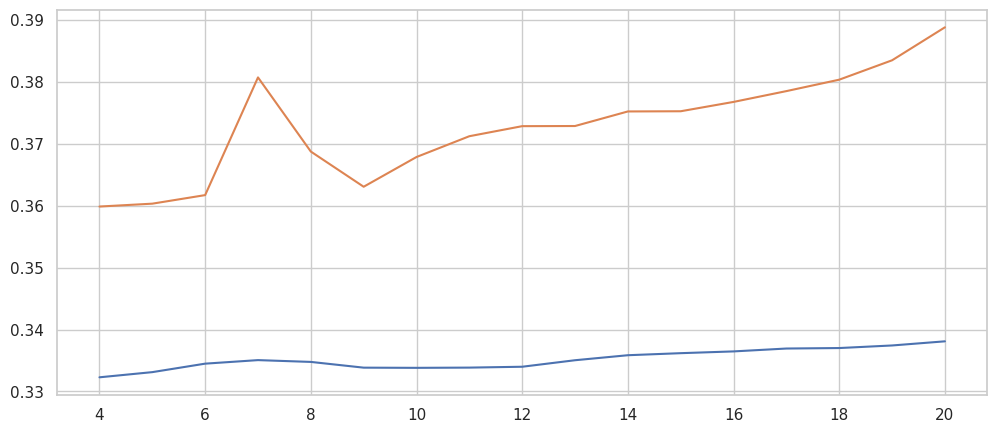

In [ ]:
plt.plot(days, metrics_train, label=["train score"])
plt.plot(days, metrics_val, label=["validation score"])

## Линейный baseline


In [ ]:
target_features = ["route_id"]
ohe_features = [col for col in feature_cols if col.endswith("_id") and col not in target_features]
numeric_features = [col for col in feature_cols if col not in target_features and col not in ohe_features]

print("Target features:", target_features)
print("One hot encoding features: ", ohe_features)
print("Numeric features:", numeric_features)


Target features: ['route_id']
One hot encoding features:  ['weekday_id']
Numeric features: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_1_lag_1', 'status_1_lag_2', 'status_1_lag_3', 'status_1_lag_4', 'status_1_lag_5', 'status_1_lag_6', 'status_1_lag_7', 'status_1_lag_8', 'status_1_lag_9', 'status_1_lag_10', 'status_1_lag_11', 'status_1_lag_12', 'status_1_lag_13', 'status_1_lag_14', 'status_1_lag_15', 'status_1_lag_16', 'status_1_lag_17', 'status_1_lag_18', 'status_1_lag_19', 'status_1_lag_20', 'status_1_lag_21', 'status_1_lag_22', 'status_1_lag_23', 'status_1_lag_24', 'status_1_lag_25', 'status_1_lag_26', 'status_1_lag_27', 'status_1_lag_28', 'status_1_lag_29', 'status_1_lag_30', 'status_1_lag_31', 'status_1_lag_32', 'status_1_lag_33', 'status_1_lag_34', 'status_1_lag_35', 'status_1_lag_36', 'status_2_lag_1', 'status_2_lag_2', 'status_2_lag_3', 'status_2_lag_4', 'status_2_lag_5', 'status_2_lag_6', 'status_2_lag_7', 'status_2_lag_8', 'status_2_lag_9',

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    #("detrend", TrendPreprocessingFeatures(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns)),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "ohe",
            OneHotEncoder(handle_unknown="ignore"),
            ohe_features,
        ),
        (
            "tar",
            OneHotEncoder(handle_unknown="ignore"),
            target_features,
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=RIDGE_ALPHA)),
    ]
)

"""
model = TransformedTargetRegressor(
    regressor=model_start,
    transformer=TrendPreprocessingTarget(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns),
    check_inverse=False
)
"""

'\nmodel = TransformedTargetRegressor(\n    regressor=model_start,\n    transformer=TrendPreprocessingTarget(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns),\n    check_inverse=False\n)\n'

In [ ]:
del train_model_df, fit_df, valid_df, train_df, supervised_df
gc.collect()

0

In [ ]:
model.fit(X_fit, y_fit)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['status_1', 'status_2',
                                                   'status_3', 'status_4',
                                                   'status_5', 'status_6',
                                                   'status_1_lag_1',
                                                   'status_1_lag_2',
                                                   'status_1_lag_3',
                                                   'status_1_lag_4',
                                                   'status_1_lag_5',
                                                   'status_1_lag_6',
                                                   'status_1_lag_7',
                                                   's...
                                                   'status_1_lag_14',
                                                   'status_1_lag_15',
                                                   'status_1_lag_16',
                                                   'status_1_lag_17',
                                                   'status_1_lag_18',
                                                   'status_1_lag_19',
                                                   'status_1_lag_20',
                                                   'status_1_lag_21',
                                                   'status_1_lag_22',
                                                   'status_1_lag_23',
                                                   'status_1_lag_24', ...]),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['weekday_id']),
                                                 ('tar',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['route_id'])])),
                ('regressor', Ridge(alpha=10.0))])

In [ ]:
fit_pred_df = pd.DataFrame(model.predict(X_fit), columns=FUTURE_TARGET_COLS, index=X_fit.index)
#valid_pred_df = pd.DataFrame(model.predict(X_valid), columns=FUTURE_TARGET_COLS, index=X_valid.index)
test_pred_df = pd.DataFrame(model.predict(X_test), columns=FUTURE_TARGET_COLS, index=test_model_df.index)

test_pred_df.head()

,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8
2314,171277.681290,202460.558736,204371.717051,192129.781156,183558.577914,173524.892234,164422.159894,165953.660826
4629,91027.376362,63536.393927,69050.331960,85780.554865,87845.122427,78492.511460,67313.591667,59745.065721
6944,26042.656708,29086.039158,43496.222324,54061.915171,61770.187172,62255.372594,59676.708653,58066.582040
9259,131632.115056,154072.574935,159585.075845,152808.154141,155287.610058,154099.360739,139176.437886,129047.872797
11574,310578.948381,314368.403119,320416.764911,335498.408744,344693.513753,357812.002679,362966.144774,355464.934490


In [ ]:
ridge_model = model.named_steps["regressor"]
features_names = preprocessor.get_feature_names_out()
coef_value = np.mean(ridge_model.coef_, axis=0)
coef_value_stand = (coef_value - np.mean(coef_value)) / np.std(coef_value)
importance = pd.DataFrame({
    "features": features_names,
    "coef": coef_value_stand
})
importance[-7:]

## XGB Baseline

In [ ]:
categorical_features = [col for col in feature_cols if col.endswith("_id")]
numeric_features = [col for col in feature_cols if col not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

target_features = ["route_id"]
ohe_features = [col for col in feature_cols if col.endswith("_id") and col not in target_features]
numeric_features = [col for col in feature_cols if col not in target_features and col not in ohe_features]

print("Target features:", target_features)
print("One hot encoding features: ", ohe_features)
print("Numeric features:", numeric_features)


Categorical features: ['route_id', 'weekday_id']
Numeric features: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_1_lag_1', 'status_1_lag_2', 'status_1_lag_3', 'status_1_lag_4', 'status_1_lag_5', 'status_1_lag_6', 'status_1_lag_7', 'status_1_lag_8', 'status_1_lag_9', 'status_1_lag_10', 'status_1_lag_11', 'status_1_lag_12', 'status_2_lag_1', 'status_2_lag_2', 'status_2_lag_3', 'status_2_lag_4', 'status_2_lag_5', 'status_2_lag_6', 'status_2_lag_7', 'status_2_lag_8', 'status_2_lag_9', 'status_2_lag_10', 'status_2_lag_11', 'status_2_lag_12', 'status_3_lag_1', 'status_3_lag_2', 'status_3_lag_3', 'status_3_lag_4', 'status_3_lag_5', 'status_3_lag_6', 'status_3_lag_7', 'status_3_lag_8', 'status_3_lag_9', 'status_3_lag_10', 'status_3_lag_11', 'status_3_lag_12', 'status_4_lag_1', 'status_4_lag_2', 'status_4_lag_3', 'status_4_lag_4', 'status_4_lag_5', 'status_4_lag_6', 'status_4_lag_7', 'status_4_lag_8', 'status_4_lag_9', 'status_4_lag_10', 'status_4_lag_11', 'st

In [ ]:
xgb_params = {
    "objective": "reg:absoluteerror",
    "n_estimators": 500,
    "learning_rate": 0.49650292881998626,
    "max_depth": 4,
    "subsample": 0.7417729089473964,
    "colsample_bytree": 0.7,
    "lambda": 40.372634183465811,
    "alpha": 90.832685112890902,
    "tree_method": "hist",
    "verbosity": 2,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}
#'max_depth': 4, 'learning_rate': 0.49650292881998626, 'reg_alpha': 9.832685112890902, 'reg_lambda': 4.372634183465811, 'subsample': 0.7417729089473964

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    #("detrend", TrendPreprocessingFeatures(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns)),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "ohe",
            OneHotEncoder(handle_unknown="ignore"),
            ohe_features,
        ),
        (
            "tar",
            OneHotEncoder(handle_unknown="ignore"),
            target_features,
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", xgb.XGBRegressor(**xgb_params)),
    ]
)

"""
model = TransformedTargetRegressor(
    regressor=model_start,
    transformer=TrendPreprocessingTarget(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns),
    check_inverse=False
)
"""

'\nmodel = TransformedTargetRegressor(\n    regressor=model_start,\n    transformer=TrendPreprocessingTarget(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns),\n    check_inverse=False\n)\n'

In [ ]:
model.fit(X_fit, y_fit)

[12:22:37] INFO: /__w/xgboost/xgboost/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (347000, 1103, 34006000).


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['status_1', 'status_2',
                                                   'status_3', 'status_4',
                                                   'status_5', 'status_6',
                                                   'status_1_lag_1',
                                                   'status_1_lag_2',
                                                   'status_1_lag_3',
                                                   'status_1_lag_4',
                                                   'status_1_lag_5',
                                                   'status_1_lag_6',
                                                   'status_1_lag_7',
                                                   's...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None,
                              lambda=40.37263418346581,
                              learning_rate=0.49650292881998626, max_bin=None,
                              max_cat_threshold=None, max_cat_to_onehot=None,
                              max_delta_step=None, max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, ...))])

In [ ]:
fit_pred_df = pd.DataFrame(model.predict(X_fit), columns=FUTURE_TARGET_COLS, index=fit_df.index)
valid_pred_df = pd.DataFrame(model.predict(X_valid), columns=FUTURE_TARGET_COLS, index=valid_df.index)
test_pred_df = pd.DataFrame(model.predict(X_test), columns=FUTURE_TARGET_COLS, index=test_model_df.index)

valid_pred_df.head()

,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8
1756991,248667.109375,181092.421875,220886.203125,207121.531250,192718.671875,180486.906250,184084.000000,195688.937500
1796346,411296.437500,343464.531250,467450.750000,397067.187500,415777.656250,428722.906250,460649.843750,399291.031250
2074146,135677.015625,149481.203125,170700.671875,200859.953125,142345.562500,149281.796875,203315.359375,170011.593750
1544011,146634.406250,141338.484375,133798.546875,154862.859375,115318.148438,89254.601562,161657.500000,133553.234375
1421316,335005.656250,356675.718750,352649.937500,315004.531250,364491.156250,385624.531250,363925.593750,375604.000000


##Ridge для каждого маршрута

In [ ]:
class EachRouteRige:
    def __init__(self, alpha, count_route=1000):
        self.alpha = alpha
        self.count_route = count_route
        self.models = [Ridge(alpha=alpha) for _ in range(count_route)]

    def fit(self, X, y):
        """
        X - pd.DataFrame (route_id + features)
        y - pd.DataFrame (route_id + targets)
        """
        self.y_count_columns = y.shape[1] - 1 # -1, так как еще и route_id передается
        for id in range(self.count_route):
            X_route = X[X["route_id"] == id].drop(columns=["route_id"])
            y_route = y[y["route_id"] == id].drop(columns=["route_id"])

            self.models[i].fit(X_route, y_route)
        return self

    def predict(self, X):
        """
        X - pd.DataFrame (route_id + features)
        """
        pred_all = pd.DataFrame(np.zeros((X.shape[0], self.y_count_columns)), index=X.index)
        for id in range(self.count_route):
            route_index = X[X["route_id"] == id].index
            X_route = X[X["route_id"] == id].drop(columns=["route_id"])
            pred = self.models[i].predict(X_route)
            pred_all.loc[route_index] = pred
        return pred_all.values

In [ ]:
target_features = ["route_id"]
ohe_features = [col for col in feature_cols if col.endswith("_id") and col not in target_features]
numeric_features = [col for col in feature_cols if col not in target_features and col not in ohe_features]

print("Target features:", target_features)
print("One hot encoding features: ", ohe_features)
print("Numeric features:", numeric_features)


Target features: ['route_id']
One hot encoding features:  ['weekday_id']
Numeric features: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'add_status_1_2', 'add_status_2_3', 'add_status_3_4', 'add_status_4_5', 'speed_status_1', 'speed_status_2', 'speed_status_3', 'speed_status_4', 'speed_status_5', 'speed_status_6', 'status_1_lag_1', 'status_1_lag_2', 'status_1_lag_3', 'status_1_lag_4', 'status_1_lag_5', 'status_2_lag_1', 'status_2_lag_2', 'status_2_lag_3', 'status_2_lag_4', 'status_2_lag_5', 'status_3_lag_1', 'status_3_lag_2', 'status_3_lag_3', 'status_3_lag_4', 'status_3_lag_5', 'status_4_lag_1', 'status_4_lag_2', 'status_4_lag_3', 'status_4_lag_4', 'status_4_lag_5', 'status_5_lag_1', 'status_5_lag_2', 'status_5_lag_3', 'status_5_lag_4', 'status_5_lag_5', 'status_6_lag_1', 'status_6_lag_2', 'status_6_lag_3', 'status_6_lag_4', 'status_6_lag_5', 'taget_1_lag', 'taget_2_lag', 'taget_3_lag', 'taget_4_lag', 'taget_5_lag', 'target_week_lag', 'target_day_lag']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("detrend", TrendPreprocessingFeatures(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns)),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "ohe",
            OneHotEncoder(handle_unknown="ignore"),
            ohe_features,
        )
        #(
         #   "tar",
          #  OneHotEncoder(handle_unknown="ignore"),
           # target_features,
        #)
    ], remainder='passthrough'
)

X_fit = preprocessor.fit_transform(X_fit)
X_valid = preprocessor.transform(X_valid)
X_test = preprocessor.transform(X_test)
"""
model = TransformedTargetRegressor(
    regressor=model_start,
    transformer=TrendPreprocessingTarget(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns),
    check_inverse=False
)
"""

'\nmodel = TransformedTargetRegressor(\n    regressor=model_start,\n    transformer=TrendPreprocessingTarget(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns),\n    check_inverse=False\n)\n'

In [ ]:
def find_route_idx_column(array, count_route=1000):
    finding_column = np.arange(count_route)
    for col in range(array.shape[1]):
        #print(np.sort(np.unique(array[:, col]))[:10])
        if np.array_equal(np.sort(np.unique(array[:, col])), finding_column):
            return col

In [ ]:
y_fit["route_id"] = train_df["route_id"]
y_valid["route_id"] = valid_df["route_id"]
fit_col_route_id = find_route_idx_column(X_fit)
valid_col_route_id = find_route_idx_column(X_valid)
test_col_route_id = find_route_idx_column(X_test)
print(fit_col_route_id)
columns = [f"{i}" for i in range(X_fit.shape[1])]
columns_fit = columns[:fit_col_route_id] + ["route_id"] + columns[fit_col_route_id+1:]
columns_valid = columns[:valid_col_route_id] + ["route_id"] + columns[valid_col_route_id+1:]
columns_test = columns[:test_col_route_id] + ["route_id"] + columns[test_col_route_id+1:]
X_fit = pd.DataFrame(X_fit, columns=columns_fit, index=y_fit.index)
X_valid = pd.DataFrame(X_valid, columns=columns_valid, index=y_valid.index)
X_test = pd.DataFrame(X_test, columns=columns_test, index=time_test.index)
X_fit.head()

60


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,route_id
1634,-1.410357,-0.672591,-0.608806,-1.103917,-1.348170,-0.458999,0.927478,-0.169607,-1.103818,-1.342121,...,-1.507944,-0.610152,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1071164,-0.492467,-0.279177,0.606569,-0.275856,-0.856665,-0.389713,0.271030,0.857265,-0.276159,-0.922758,...,0.158972,-0.356353,0.0,0.0,0.0,0.0,0.0,1.0,0.0,462.0
2103654,-0.186503,-0.357860,-0.978702,0.276649,0.177684,-0.104659,-0.197862,-0.797139,0.277113,0.155335,...,0.669497,-0.616294,0.0,0.0,0.0,0.0,0.0,1.0,0.0,908.0
434539,0.807879,-0.200494,-0.503121,2.375150,4.283581,-0.427733,-1.229424,-0.397800,2.375720,4.450435,...,1.131091,0.377315,0.0,0.0,0.0,0.0,0.0,1.0,0.0,187.0
1073479,-1.180885,-1.223370,-0.767333,-1.009213,-0.855749,-0.451279,-0.010306,0.058587,-1.009031,-0.801215,...,-0.702161,-1.191312,0.0,0.0,0.0,0.0,0.0,1.0,0.0,463.0


In [ ]:
model = EachRouteRige(alpha=10)
model.fit(X_fit, y_fit)

In [ ]:
fit_pred_df = pd.DataFrame(model.predict(X_fit), columns=FUTURE_TARGET_COLS, index=fit_df.index)
valid_pred_df = pd.DataFrame(model.predict(X_valid), columns=FUTURE_TARGET_COLS, index=valid_df.index)
test_pred_df = pd.DataFrame(model.predict(X_test), columns=FUTURE_TARGET_COLS, index=test_model_df.index)

test_pred_df.head()

,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8
2314,266382.800403,451587.282438,499970.202192,485798.971116,478989.189841,427210.216717,414549.579331,421421.571435
4629,236851.689088,339212.205832,346944.355406,354461.121725,387271.198963,349004.356109,344296.181126,368415.775004
6944,206810.883445,352588.825460,426846.765258,462546.799417,470065.649598,416595.006429,416629.638453,437709.272624
9259,157064.447101,284071.637027,326637.912697,371158.251992,432960.852236,394340.537999,359388.639444,393388.581281
11574,266510.139736,335046.588921,395652.510725,384465.037083,410577.024351,401916.459782,464059.840285,471404.836713


In [ ]:
y_fit.drop(columns=["route_id"], inplace=True)
y_valid.drop(columns=["route_id"], inplace=True)

##Подбор параметров для XGB

In [ ]:
feature_cols = [col for col in train_df.columns if col not in {TARGET_COL, "timestamp", "id", *FUTURE_TARGET_COLS}]

print("Feature columns:", feature_cols)

target_features = []
ohe_features = [col for col in feature_cols if col.endswith("_id") and col not in target_features]
numeric_features = [col for col in feature_cols if col not in target_features and col not in ohe_features]

print("Target features:", target_features)
print("One hot encoding features: ", ohe_features)
print("Numeric features:", numeric_features)


Feature columns: ['route_id', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'weekday_id', 'status_1_lag_1', 'status_1_lag_2', 'status_1_lag_3', 'status_1_lag_4', 'status_1_lag_5', 'status_2_lag_1', 'status_2_lag_2', 'status_2_lag_3', 'status_2_lag_4', 'status_2_lag_5', 'status_3_lag_1', 'status_3_lag_2', 'status_3_lag_3', 'status_3_lag_4', 'status_3_lag_5', 'status_4_lag_1', 'status_4_lag_2', 'status_4_lag_3', 'status_4_lag_4', 'status_4_lag_5', 'status_5_lag_1', 'status_5_lag_2', 'status_5_lag_3', 'status_5_lag_4', 'status_5_lag_5', 'status_6_lag_1', 'status_6_lag_2', 'status_6_lag_3', 'status_6_lag_4', 'status_6_lag_5', 'taget_1_lag', 'taget_2_lag', 'taget_3_lag', 'taget_4_lag', 'taget_5_lag', 'target_week_lag', 'target_day_lag']
Target features: []
One hot encoding features:  ['route_id', 'weekday_id']
Numeric features: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_1_lag_1', 'status_1_lag_2', 'status_1_lag_3', 'status_1_la

In [ ]:
def take_model(time_fit, time_valid, numeric_features, ohe_features, target_features, params, time_test=None):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("detrend", TrendPreprocessingFeatures(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns)),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "ohe",
                OneHotEncoder(handle_unknown="ignore"),
                ohe_features,
            ),
            (
                "tar",
                OneHotEncoder(handle_unknown="ignore"),
                target_features,
            )
        ]
    )

    model_start = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", xgb.XGBRegressor(**params)),
        ]
    )


    model = TransformedTargetRegressor(
        regressor=model_start,
        transformer=TrendPreprocessingTarget(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns),
        check_inverse=False
    )
    return model

In [ ]:
class WapePlusRbias:
    """Calculates as WAPE + Relative Bias."""

    @property
    def name(self) -> str:
        """Возвращает имя метрики."""
        return "wape_plus_rbias"

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Рассчитывает значение метрики."""
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias

In [ ]:
def objective(trial, X, target, T):
    """
    X - фичи, по которым будут предсказываться таргеты X - pd.DataFrame
    target - таргеты - 8 лагов отгрузки target - pd.DataFrame
    T - время, соответствующее T - pd.Series
    """
    metric = WapePlusRbias()
    max_depth = trial.suggest_int("max_depth", 4, 12)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.5)
    n_estimators = 500#trial.suggest_int("n_estimators", 100, 650)
    reg_alpha = trial.suggest_float("reg_alpha", 0.05, 1)
    reg_lambda = trial.suggest_float("reg_lambda", 0.05, 1)
    subsample = trial.suggest_float("subsample", 0.8, 0.95)


    params={
        'objective': 'reg:absoluteerror',
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'n_estimators': n_estimators,
        'subsample': subsample,
        'colsample_bytree': 1,
        'reg_alpha': reg_alpha,
        'reg_lambda': reg_lambda,
        'random_state': RANDOM_STATE,
        'eval_metric': 'mape',
        'tree_method' : 'hist',
        'device': "cuda" if torch.cuda.is_available() else "cpu",
      }


    n_splits = 2
    length_train_window = TRAIN_DAYS * 48 * 1000
    length_test_window = 1000
    tscv = TimeSeriesSplit(
        n_splits=n_splits,
        max_train_size=length_train_window,
        test_size=length_test_window
    )

    m = 0
    for train_idx, val_idx in tscv.split(X):
        xgb_model = take_model(T.iloc[train_idx], T.iloc[val_idx],
                               numeric_features, ohe_features,target_features, params)

        xgb_model.fit(X.iloc[train_idx], target.iloc[train_idx])
        pred = xgb_model.predict(X.iloc[val_idx])
        m += metric.calculate(y_true=target.iloc[val_idx].to_numpy().flatten(), y_pred=pred.flatten())

    return m / n_splits

In [ ]:
optuna.logging.set_verbosity(optuna.logging.INFO)

In [ ]:
study = optuna.create_study(
    direction = "minimize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=20,
        seed=RANDOM_STATE,
        multivariate=True,
        group=True
    )
)
print("start!")
study.optimize(lambda trial: objective(trial, X=train_model_df[feature_cols],
                                       target=train_model_df[FUTURE_TARGET_COLS],
                                       T=train_model_df["source_timestamp"]),
                n_trials=100
               )

/tmp/ipykernel_199/2260885146.py:3: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
/tmp/ipykernel_199/2260885146.py:3: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
[I 2026-03-28 17:54:27,481] A new study created in memory with name: no-name-7a9978c0-9fdb-4cb3-90b1-366847d823d4


start!


[I 2026-03-28 17:57:39,906] Trial 0 finished with value: 0.3941842088532777 and parameters: {'max_depth': 7, 'learning_rate': 0.4758500101408589, 'reg_alpha': 0.7453942447208348, 'reg_lambda': 0.6187255599871848, 'subsample': 0.8234027960663655}. Best is trial 0 with value: 0.3941842088532777.
[I 2026-03-28 18:00:16,398] Trial 1 finished with value: 0.40306749357478544 and parameters: {'max_depth': 5, 'learning_rate': 0.03846096996241773, 'reg_alpha': 0.8728673384861885, 'reg_lambda': 0.6210592611560484, 'subsample': 0.9062108866694067}. Best is trial 0 with value: 0.3941842088532777.
[I 2026-03-28 18:02:30,558] Trial 2 finished with value: 0.39284330466875605 and parameters: {'max_depth': 4, 'learning_rate': 0.48525582755937724, 'reg_alpha': 0.8408205087604007, 'reg_lambda': 0.25172215514436236, 'subsample': 0.8272737450810651}. Best is trial 2 with value: 0.39284330466875605.
[I 2026-03-28 18:04:58,951] Trial 3 finished with value: 0.39590863285058436 and parameters: {'max_depth': 5,

[I 2026-03-28 14:29:01,533] Trial 0 finished with value: 0.39467534330447623 and parameters: {'max_depth': 7, 'learning_rate': 0.4758500101408589, 'reg_alpha': 7.33333972102348, 'reg_lambda': 6.0066519177605135, 'subsample': 0.7312037280884873}. Best is trial 0 with value: 0.39467534330447623.

[I 2026-03-28 14:31:58,125] Trial 1 finished with value: 0.4005567283393612 and parameters: {'max_depth': 5, 'learning_rate': 0.03846096996241773, 'reg_alpha': 8.668452650460605, 'reg_lambda': 6.031094366844927, 'subsample': 0.8416145155592091}. Best is trial 0 with value: 0.39467534330447623.

[I 2026-03-28 14:34:30,087] Trial 2 finished with value: 0.3857970765584856 and parameters: {'max_depth': 4, 'learning_rate': 0.48525582755937724, 'reg_alpha': 8.332804275964197, 'reg_lambda': 2.1627741512488474, 'subsample': 0.73636499344142}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 14:37:17,880] Trial 3 finished with value: 0.3916550248494223 and parameters: {'max_depth': 5, 'learning_rate': 0.1590786990501735, 'reg_alpha': 5.271326494740766, 'reg_lambda': 4.347852935489051, 'subsample': 0.7582458280396084}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 14:42:55,765] Trial 4 finished with value: 0.3921687341395599 and parameters: {'max_depth': 9, 'learning_rate': 0.0783519917195005, 'reg_alpha': 2.95683925292542, 'reg_lambda': 3.695300340772232, 'subsample': 0.7912139968434072}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 14:52:14,161] Trial 5 finished with value: 0.38827445336905564 and parameters: {'max_depth': 11, 'learning_rate': 0.10784015325759626, 'reg_alpha': 5.166632662215435, 'reg_lambda': 5.944524960177322, 'subsample': 0.7092900825439995}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 14:57:41,367] Trial 6 finished with value: 0.39267764584748066 and parameters: {'max_depth': 9, 'learning_rate': 0.09355682060677284, 'reg_alpha': 0.6972633502035311, 'reg_lambda': 9.491411095670665, 'subsample': 0.8931264066149118}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 15:06:36,062] Trial 7 finished with value: 0.3873793580154356 and parameters: {'max_depth': 11, 'learning_rate': 0.15926074689495165, 'reg_alpha': 1.0218375343635193, 'reg_lambda': 6.85811861379596, 'subsample': 0.7880304987479203}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 15:09:19,756] Trial 8 finished with value: 0.38958964480416236 and parameters: {'max_depth': 5, 'learning_rate': 0.2526366859545224, 'reg_alpha': 0.392165785096423, 'reg_lambda': 9.097738000683881, 'subsample': 0.7517559963200033}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 15:14:48,322] Trial 9 finished with value: 0.3903281821719753 and parameters: {'max_depth': 9, 'learning_rate': 0.16273842728381138, 'reg_alpha': 5.224676810719217, 'reg_lambda': 5.489767279465632, 'subsample': 0.7369708911051054}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 15:27:27,887] Trial 10 finished with value: 0.39886678814904236 and parameters: {'max_depth': 12, 'learning_rate': 0.38981508344694615, 'reg_alpha': 9.398014468563682, 'reg_lambda': 8.953532136755106, 'subsample': 0.819579995762217}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 15:40:26,277] Trial 11 finished with value: 0.39070256063261244 and parameters: {'max_depth': 12, 'learning_rate': 0.05336132600544055, 'reg_alpha': 2.0000294810704946, 'reg_lambda': 0.5000115246598538, 'subsample': 0.7650660661526528}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 15:44:03,460] Trial 12 finished with value: 0.3919450471575701
and parameters: {'max_depth': 7, 'learning_rate': 0.142961025569209, 'reg_alpha': 8.295938216061698, 'reg_lambda': 3.599695600601213, 'subsample': 0.7561869019374762}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 15:48:28,869] Trial 13 finished with value: 0.39419352325489 and parameters: {'max_depth': 8, 'learning_rate': 0.07905287023763369, 'reg_alpha': 8.031859958502695, 'reg_lambda': 0.7917789046137197, 'subsample': 0.8973773873201034}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 15:55:19,392] Trial 14 finished with value: 0.3890039673335975 and parameters: {'max_depth': 10, 'learning_rate': 0.10737068395174447, 'reg_alpha': 0.10494506537984387, 'reg_lambda': 8.1638412131256, 'subsample': 0.8413714687695234}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:02:02,983] Trial 15 finished with value: 0.396932403230959 and parameters: {'max_depth': 10, 'learning_rate': 0.3879224698761134, 'reg_alpha': 0.7867442847541991, 'reg_lambda': 3.616733999015512, 'subsample': 0.7231738119050259}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:11:04,835] Trial 16 finished with value: 0.39598970319232824 and parameters: {'max_depth': 11, 'learning_rate': 0.3154160821455034, 'reg_alpha': 3.342435347283859, 'reg_lambda': 0.6824055853459352, 'subsample': 0.7621964643431324}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:14:13,478] Trial 17 finished with value: 0.3889721815636066 and parameters: {'max_depth': 6, 'learning_rate': 0.3675070273856514, 'reg_alpha': 6.39369683998437, 'reg_lambda': 8.87776678863445, 'subsample': 0.7944429850323899}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:17:00,249] Trial 18 finished with value: 0.3871344913382093 and parameters: {'max_depth': 5, 'learning_rate': 0.35948994573926757, 'reg_alpha': 7.619811233738129, 'reg_lambda': 5.634708115816487, 'subsample': 0.8541934359909122}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:21:25,194] Trial 19 finished with value: 0.3904155905524396 and parameters: {'max_depth': 8, 'learning_rate': 0.2661390863971771, 'reg_alpha': 4.304033132667568, 'reg_lambda': 0.3029203111037471, 'subsample': 0.7215782853986609}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:24:11,569] Trial 20 finished with value: 0.3879994331951952 and parameters: {'max_depth': 5, 'learning_rate': 0.3992018106055843, 'reg_alpha': 8.19219487106016, 'reg_lambda': 1.0480887322333932, 'subsample': 0.7339924831397429}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:27:19,064] Trial 21 finished with value: 0.38887665374365266 and parameters: {'max_depth': 6, 'learning_rate': 0.4458287720477315, 'reg_alpha': 7.3418167278998485, 'reg_lambda': 5.884990415149359, 'subsample': 0.874651028654003}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:30:05,860] Trial 22 finished with value: 0.38790189951175796 and parameters: {'max_depth': 5, 'learning_rate': 0.28753586905144113, 'reg_alpha': 9.298103619704232, 'reg_lambda': 5.172972464514486, 'subsample': 0.8432229584459568}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:36:45,965] Trial 23 finished with value: 0.3899669727293894 and parameters: {'max_depth': 10, 'learning_rate': 0.11649042895570838, 'reg_alpha': 0.22124235087690047, 'reg_lambda': 6.481519967175389, 'subsample': 0.7462295975794568}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:39:32,097] Trial 24 finished with value: 0.3891261072755792 and parameters: {'max_depth': 5, 'learning_rate': 0.4569823384830315, 'reg_alpha': 7.2320655800291265, 'reg_lambda': 1.4754077221759663, 'subsample': 0.8322939513331089}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:42:03,735] Trial 25 finished with value: 0.3861141015437924 and parameters: {'max_depth': 4, 'learning_rate': 0.40788182232456144, 'reg_alpha': 3.9868080478767114, 'reg_lambda': 0.42345064297908475, 'subsample': 0.7184736799292045}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:44:35,592] Trial 26 finished with value: 0.38631642609443495 and parameters: {'max_depth': 4, 'learning_rate': 0.40488978651770097, 'reg_alpha': 2.210565736070011, 'reg_lambda': 0.3576110063774247, 'subsample': 0.7509240354199677}. Best is trial 2 with value: 0.3857970765584856.

[I 2026-03-28 16:47:20,571] Trial 27 finished with value: 0.38579299901181746 and parameters: {'max_depth': 5, 'learning_rate': 0.48225091207286896, 'reg_alpha': 1.1951590463849633, 'reg_lambda': 2.1122516867563315, 'subsample': 0.7694423149049702}. Best is trial 27 with value: 0.38579299901181746.

[I 2026-03-28 16:50:04,472] Trial 28 finished with value: 0.38647580093111467 and parameters: {'max_depth': 5, 'learning_rate': 0.46464093414313484, 'reg_alpha': 0.5697718470480294, 'reg_lambda': 3.3969166723054265, 'subsample': 0.8043197068081711}. Best is trial 27 with value: 0.38579299901181746.

[I 2026-03-28 16:52:37,091] Trial 29 finished with value: 0.38483868594748094 and parameters: {'max_depth': 4, 'learning_rate': 0.49650292881998626, 'reg_alpha': 9.832685112890902, 'reg_lambda': 4.372634183465811, 'subsample': 0.7417729089473964}. Best is trial 29 with value: 0.38483868594748094.

[I 2026-03-28 16:55:25,598] Trial 30 finished with value: 0.38889514081566945 and parameters: {'max_depth': 5, 'learning_rate': 0.4768570924219626, 'reg_alpha': 9.473675499589817, 'reg_lambda': 6.193961706633545, 'subsample': 0.7033372314012172}. Best is trial 29 with value: 0.38483868594748094.

[I 2026-03-28 16:58:13,645] Trial 31 finished with value: 0.390660726925236 and parameters: {'max_depth': 5, 'learning_rate': 0.49928657189263176, 'reg_alpha': 9.955387110925217, 'reg_lambda': 2.814041505968821, 'subsample': 0.7667762110559706}. Best is trial 29 with value: 0.38483868594748094.

[I 2026-03-28 17:00:43,167] Trial 32 finished with value: 0.3859007922979588 and parameters: {'max_depth': 4, 'learning_rate': 0.3570022712331691, 'reg_alpha': 5.2859588565270315, 'reg_lambda': 0.548435319234473, 'subsample': 0.7137788354956702}. Best is trial 29 with value: 0.38483868594748094.

[I 2026-03-28 17:03:12,457] Trial 33 finished with value: 0.3875878766753189 and parameters: {'max_depth': 4, 'learning_rate': 0.47628489323061574, 'reg_alpha': 7.429845590684314, 'reg_lambda': 6.01554058073187, 'subsample': 0.7592853918679006}. Best is trial 29 with value: 0.38483868594748094.

[W 2026-03-28 17:05:09,917] Trial 34 failed with parameters: {'max_depth': 4, 'learning_rate': 0.4407543689965988, 'reg_alpha': 8.982071381626458, 'reg_lambda': 3.0161391554567647, 'subsample': 0.7188544609582121} because of the following error: KeyboardInterrupt().

[I 2026-03-28 17:13:40,331] Trial 0 finished with value: 0.3977551196539092 and parameters: {'max_depth': 7, 'learning_rate': 0.4758500101408589, 'reg_alpha': 7.33333972102348, 'reg_lambda': 6.0066519177605135, 'subsample': 0.7312037280884873}. Best is trial 0 with value: 0.3977551196539092.

[I 2026-03-28 17:16:19,483] Trial 1 finished with value: 0.40334296751299276 and parameters: {'max_depth': 5, 'learning_rate': 0.03846096996241773, 'reg_alpha': 8.668452650460605, 'reg_lambda': 6.031094366844927, 'subsample': 0.8416145155592091}. Best is trial 0 with value: 0.3977551196539092.

[I 2026-03-28 17:18:37,325] Trial 2 finished with value: 0.39151059568908414 and parameters: {'max_depth': 4, 'learning_rate': 0.48525582755937724, 'reg_alpha': 8.332804275964197, 'reg_lambda': 2.1627741512488474, 'subsample': 0.73636499344142}. Best is trial 2 with value: 0.39151059568908414.

[I 2026-03-28 17:21:08,317] Trial 3 finished with value: 0.39802825030043787 and parameters: {'max_depth': 5, 'learning_rate': 0.1590786990501735, 'reg_alpha': 5.271326494740766, 'reg_lambda': 4.347852935489051, 'subsample': 0.7582458280396084}. Best is trial 2 with value: 0.39151059568908414.

[I 2026-03-28 17:26:17,183] Trial 4 finished with value: 0.39699209972685034 and parameters: {'max_depth': 9, 'learning_rate': 0.0783519917195005, 'reg_alpha': 2.95683925292542, 'reg_lambda': 3.695300340772232, 'subsample': 0.7912139968434072}. Best is trial 2 with value: 0.39151059568908414.

[I 2026-03-28 17:34:33,956] Trial 5 finished with value: 0.3914534953154677 and parameters: {'max_depth': 11, 'learning_rate': 0.10784015325759626, 'reg_alpha': 5.166632662215435, 'reg_lambda': 5.944524960177322, 'subsample': 0.7092900825439995}. Best is trial 5 with value: 0.3914534953154677.

[I 2026-03-28 17:39:31,578] Trial 6 finished with value: 0.39668087300376215 and parameters: {'max_depth': 9, 'learning_rate': 0.09355682060677284, 'reg_alpha': 0.6972633502035311, 'reg_lambda': 9.491411095670665, 'subsample': 0.8931264066149118}. Best is trial 5 with value: 0.3914534953154677.

[I 2026-03-28 17:47:32,900] Trial 7 finished with value: 0.39140140521742905 and parameters: {'max_depth': 11, 'learning_rate': 0.15926074689495165, 'reg_alpha': 1.0218375343635193, 'reg_lambda': 6.85811861379596, 'subsample': 0.7880304987479203}. Best is trial 7 with value: 0.39140140521742905.

[I 2026-03-28 17:50:00,501] Trial 8 finished with value: 0.3942864653988343 and parameters: {'max_depth': 5, 'learning_rate': 0.2526366859545224, 'reg_alpha': 0.392165785096423, 'reg_lambda': 9.097738000683881, 'subsample': 0.7517559963200033}. Best is trial 7 with value: 0.39140140521742905.

##Подбор параметров для Ridge

In [ ]:
feature_cols = [col for col in train_df.columns if col not in {TARGET_COL, "timestamp", "id", *FUTURE_TARGET_COLS}]

print("Feature columns:", feature_cols)

target_features = []
ohe_features = [col for col in feature_cols if col.endswith("_id") and col not in target_features]
numeric_features = [col for col in feature_cols if col not in target_features and col not in ohe_features]

print("Target features:", target_features)
print("One hot encoding features: ", ohe_features)
print("Numeric features:", numeric_features)


Feature columns: ['route_id', 'status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'add_status_1_2', 'add_status_2_3', 'add_status_3_4', 'add_status_4_5', 'speed_status_1', 'speed_status_2', 'speed_status_3', 'speed_status_4', 'speed_status_5', 'speed_status_6', 'weekday_id', 'status_1_lag_1', 'status_1_lag_2', 'status_1_lag_3', 'status_1_lag_4', 'status_1_lag_5', 'status_2_lag_1', 'status_2_lag_2', 'status_2_lag_3', 'status_2_lag_4', 'status_2_lag_5', 'status_3_lag_1', 'status_3_lag_2', 'status_3_lag_3', 'status_3_lag_4', 'status_3_lag_5', 'status_4_lag_1', 'status_4_lag_2', 'status_4_lag_3', 'status_4_lag_4', 'status_4_lag_5', 'status_5_lag_1', 'status_5_lag_2', 'status_5_lag_3', 'status_5_lag_4', 'status_5_lag_5', 'status_6_lag_1', 'status_6_lag_2', 'status_6_lag_3', 'status_6_lag_4', 'status_6_lag_5', 'taget_1_lag', 'taget_2_lag', 'taget_3_lag', 'taget_4_lag', 'taget_5_lag', 'taget_6_lag', 'taget_7_lag', 'taget_8_lag', 'taget_9_lag', 'taget_10_lag', 'taget_11_lag

In [ ]:
def take_model(time_fit, time_valid, numeric_features, ohe_features, target_features, params, time_test=None):
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("detrend", TrendPreprocessingFeatures(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns)),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "ohe",
                OneHotEncoder(handle_unknown="ignore"),
                ohe_features,
            ),
            (
                "tar",
                OneHotEncoder(handle_unknown="ignore"),
                target_features,
            )
        ]
    )

    model_start = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", Ridge(**params)),
        ]
    )


    model = TransformedTargetRegressor(
        regressor=model_start,
        transformer=TrendPreprocessingTarget(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns),
        check_inverse=False
    )
    return model

In [ ]:
class WapePlusRbias:
    """Calculates as WAPE + Relative Bias."""

    @property
    def name(self) -> str:
        """Возвращает имя метрики."""
        return "wape_plus_rbias"

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Рассчитывает значение метрики."""
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias
metric = WapePlusRbias()

In [ ]:
def objective(trial, X, target, T):
    """
    X - фичи, по которым будут предсказываться таргеты X - pd.DataFrame
    target - таргеты - 8 лагов отгрузки target - pd.DataFrame
    T - время, соответствующее T - pd.Series
    """


    params={
        "alpha": trial.suggest_float("alpha", 1e-2, 1e2)
      }


    n_splits = 3
    length_train_window = TRAIN_DAYS * 48 * 1000
    length_test_window = 1000
    tscv = TimeSeriesSplit(
        n_splits=n_splits,
        max_train_size=length_train_window,
        test_size=length_test_window
    )

    m = 0
    for train_idx, val_idx in tscv.split(X):
        ridge_model = take_model(T.iloc[train_idx], T.iloc[val_idx],
                               numeric_features, ohe_features,target_features, params)

        ridge_model.fit(X.iloc[train_idx], target.iloc[train_idx])
        pred = ridge_model.predict(X.iloc[val_idx])
        m += metric.calculate(y_true=target.iloc[val_idx].to_numpy().flatten(), y_pred=pred.flatten())

    return m / n_splits

In [ ]:
study = optuna.create_study(
    direction = "minimize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=20,
        seed=RANDOM_STATE,
        multivariate=True,
        group=True
    )
)
print("start!")
study.optimize(lambda trial: objective(trial, X=train_model_df[feature_cols],
                                       target=train_model_df[FUTURE_TARGET_COLS],
                                       T=train_model_df["source_timestamp"]),
                n_trials=100
               )

/tmp/ipykernel_14579/879992793.py:3: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
/tmp/ipykernel_14579/879992793.py:3: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(
[I 2026-03-30 08:55:49,619] A new study created in memory with name: no-name-8555a5ab-33c1-41f8-be05-2ceabe571491


start!


[I 2026-03-30 09:11:35,064] Trial 0 finished with value: 0.35716117880365533 and parameters: {'alpha': 37.46026648354777}. Best is trial 0 with value: 0.35716117880365533.
[I 2026-03-30 09:25:57,467] Trial 1 finished with value: 0.35557433854702786 and parameters: {'alpha': 95.07192349792751}. Best is trial 1 with value: 0.35557433854702786.
[I 2026-03-30 09:41:26,068] Trial 2 finished with value: 0.35608463010115426 and parameters: {'alpha': 73.2020742417224}. Best is trial 1 with value: 0.35557433854702786.
[I 2026-03-30 09:56:41,885] Trial 3 finished with value: 0.3565137303788624 and parameters: {'alpha': 59.86986183486169}. Best is trial 1 with value: 0.35557433854702786.
[I 2026-03-30 10:12:39,970] Trial 4 finished with value: 0.35914031238969685 and parameters: {'alpha': 15.610303857839227}. Best is trial 1 with value: 0.35557433854702786.
[I 2026-03-30 10:28:37,027] Trial 5 finished with value: 0.35909040277734205 and parameters: {'alpha': 15.607892088416902}. Best is trial 1 w

##TabM

In [ ]:
!pip install pytabkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.3 MB/s eta 0:00:00


In [ ]:
from pytabkit import TabM_D_Regressor

In [ ]:
target_features = ["route_id"]
ohe_features = [col for col in feature_cols if col.endswith("_id") and col not in target_features]
numeric_features = [col for col in feature_cols if col not in target_features and col not in ohe_features]

print("Target features:", target_features)
print("One hot encoding features: ", ohe_features)
print("Numeric features:", numeric_features)

Target features: ['route_id']
One hot encoding features:  ['weekday_id']
Numeric features: ['status_1', 'status_2', 'status_3', 'status_4', 'status_5', 'status_6', 'status_1_lag_1', 'status_1_lag_2', 'status_1_lag_3', 'status_1_lag_4', 'status_1_lag_5', 'status_1_lag_6', 'status_1_lag_7', 'status_1_lag_8', 'status_1_lag_9', 'status_1_lag_10', 'status_1_lag_11', 'status_1_lag_12', 'status_1_lag_13', 'status_1_lag_14', 'status_1_lag_15', 'status_1_lag_16', 'status_1_lag_17', 'status_1_lag_18', 'status_1_lag_19', 'status_1_lag_20', 'status_1_lag_21', 'status_1_lag_22', 'status_1_lag_23', 'status_1_lag_24', 'status_1_lag_25', 'status_1_lag_26', 'status_1_lag_27', 'status_1_lag_28', 'status_1_lag_29', 'status_1_lag_30', 'status_1_lag_31', 'status_1_lag_32', 'status_1_lag_33', 'status_1_lag_34', 'status_1_lag_35', 'status_1_lag_36', 'status_2_lag_1', 'status_2_lag_2', 'status_2_lag_3', 'status_2_lag_4', 'status_2_lag_5', 'status_2_lag_6', 'status_2_lag_7', 'status_2_lag_8', 'status_2_lag_9',

In [ ]:
dict_tabm_params = {
    'batch_size': 'auto',
    'patience': 16,
    'allow_amp': True,
    'arch_type': 'tabm-mini',
    'tabm_k': 8,
    'gradient_clipping_norm': 1.0,
    'share_training_batches': False,
    'lr': 0.003,
    'weight_decay': 0.01,
    'n_blocks': 3,
    'd_block': 32,
    'dropout': 0.05,
    'num_emb_type': 'pwl',
    'd_embedding': 32,
    'num_emb_n_bins': 150,
    "device": "cuda:0"
}

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                   # ("detrend", TrendPreprocessingFeatures(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns)),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "ohe",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ohe_features,
        ),
        (
            "tar",
            MultitargetTargetEncoding(target_features),
            target_features,
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", MultiOutputRegressor(TabM_D_Regressor(**dict_tabm_params))),
    ]
)

"""
model = TransformedTargetRegressor(
    regressor=model_start,
    transformer=TrendPreprocessingTarget(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns),
    check_inverse=False
)
"""

'\nmodel = TransformedTargetRegressor(\n    regressor=model_start,\n    transformer=TrendPreprocessingTarget(train_time=time_fit, val_time=time_valid, test_time=time_test, cols=X_fit.columns),\n    check_inverse=False\n)\n'

In [ ]:
del train_model_df, fit_df, valid_df, train_df, supervised_df
gc.collect()

240

In [ ]:
model.fit(X_fit, y_fit)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytabkit/models/nn_models/rtdl_num_embeddings.py:311: UserWarning: The 261-th feature has just two bin edges, which means only one bin. Strictly speaking, using a single bin for the piecewise-linear encoding should not break anything, but it is the same as using sklearn.preprocessing.MinMaxScaler
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pytabkit/models/nn_models/rtdl_num_embeddings.py:311: UserWarning: The 262-th feature has just two bin edges, which means only one bin. Strictly speaking, using a single bin for the piecewise-linear encoding should 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['status_1', 'status_2',
                                                   'status_3', 'status_4',
                                                   'status_5', 'status_6',
                                                   'status_1_lag_1',
                                                   'status_1_lag_2',
                                                   'status_1_lag_3',
                                                   'status_1_lag_4',
                                                   'status_1_lag_5',
                                                   'status_1_lag_6',
                                                   'status_1_lag_7',
                                                   's...
                                                  MultitargetTargetEncoding(cols=['route_id']),
                                                  ['route_id'])])),
                ('regressor',
                 MultiOutputRegressor(estimator=TabM_D_Regressor(allow_amp=True,
                                                                 arch_type='tabm-mini',
                                                                 batch_size='auto',
                                                                 d_block=32,
                                                                 d_embedding=32,
                                                                 device='cuda:0',
                                                                 dropout=0.05,
                                                                 gradient_clipping_norm=1.0,
                                                                 lr=0.003,
                                                                 n_blocks=3,
                                                                 num_emb_n_bins=150,
                                                                 num_emb_type='pwl',
                                                                 patience=16,
                                                                 share_training_batches=False,
                                                                 tabm_k=8,
                                                                 weight_decay=0.01)))])

In [ ]:
fit_pred_df = pd.DataFrame(model.predict(X_fit), columns=FUTURE_TARGET_COLS, index=X_fit.index)
valid_pred_df = pd.DataFrame(model.predict(X_valid), columns=FUTURE_TARGET_COLS, index=X_valid.index)
test_pred_df = pd.DataFrame(model.predict(X_test), columns=FUTURE_TARGET_COLS, index=test_model_df.index)

test_pred_df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

,target_step_1,target_step_2,target_step_3,target_step_4,target_step_5,target_step_6,target_step_7,target_step_8
2314,201882.50000,195835.015625,192572.281250,188776.968750,180503.87500,168813.921875,168042.500000,165188.671875
4629,137562.18750,104534.281250,87703.656250,108227.234375,97955.25000,98319.296875,94933.250000,94121.015625
6944,58936.59375,49699.078125,58969.546875,81166.843750,65607.59375,77241.031250,83533.125000,87542.125000
9259,160428.34375,158976.218750,188590.578125,164942.187500,153388.87500,147804.968750,146125.859375,142654.375000
11574,304275.68750,342082.281250,344169.937500,331843.656250,348712.75000,331004.125000,345193.312500,342345.906250


##

## Метрики


In [ ]:
class WapePlusRbias:
    """Calculates as WAPE + Relative Bias."""

    @property
    def name(self) -> str:
        """Возвращает имя метрики."""
        return "wape_plus_rbias"

    def calculate(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        """Рассчитывает значение метрики."""
        wape = (np.abs(y_pred - y_true)).sum() / y_true.sum()
        rbias = np.abs(y_pred.sum() / y_true.sum() - 1)
        return wape + rbias


metric = WapePlusRbias()

In [ ]:
print('Метрики на тесте (по горизонтам):')
display(np.round(metric.calculate(y_fit, fit_pred_df), 4))

print('Общая метрика на тесте:')
print(f'{metric.calculate(y_fit.to_numpy().flatten(), fit_pred_df.to_numpy().flatten()):.4f}')

"""
first feature engeniring:
target_step_1	0.3090
target_step_2	0.3340
target_step_3	0.3375
target_step_4	0.3427
target_step_5	0.3458
target_step_6	0.3474
target_step_7	0.3480
target_step_8	0.3479

dtype: float64
Общая метрика на тесте:
0.3390

no feature engeniring
target_step_1	0.3201
target_step_2	0.3375
target_step_3	0.3399
target_step_4	0.3439
target_step_5	0.3466
target_step_6	0.3478
target_step_7	0.3484
target_step_8	0.3487

dtype: float64
Общая метрика на тесте:
0.3416

first feature engeniring + p=5 lags by each status
arget_step_1	0.3076
target_step_2	0.3304
target_step_3	0.3340
target_step_4	0.3407
target_step_5	0.3445
target_step_6	0.3462
target_step_7	0.3469
target_step_8	0.3472

dtype: float64
Общая метрика на тесте:
0.3372

first feature engeniring + p=5 lags by each status and route_id not ohe this target_encoding
target_step_1	0.3119
target_step_2	0.3338
target_step_3	0.3364
target_step_4	0.3423
target_step_5	0.3455
target_step_6	0.3468
target_step_7	0.3473
target_step_8	0.3476

dtype: float64
Общая метрика на тесте:
0.3389

ohe + 5 lags target + 5 lags status + all status
arget_step_1	0.3030
target_step_2	0.3309
target_step_3	0.3350
target_step_4	0.3420
target_step_5	0.3458
target_step_6	0.3475
target_step_7	0.3481
target_step_8	0.3484

dtype: float64
Общая метрика на тесте:
0.3376

ohe + 5 lags target + 5 lags status + all status + detrend features
target_step_1	0.3011
target_step_2	0.3299
target_step_3	0.3341
target_step_4	0.3409
target_step_5	0.3446
target_step_6	0.3463
target_step_7	0.3469
target_step_8	0.3473

dtype: float64
Общая метрика на тесте:
0.3364

ohe + 5 lags target + 5 lags status + all status + detrend features + detrend targets + week seasonal + day seasonal - Ridge
target_step_1	0.3011
target_step_2	0.3298
target_step_3	0.3340
target_step_4	0.3409
target_step_5	0.3446
target_step_6	0.3463
target_step_7	0.3469
target_step_8	0.3473

dtype: float64
Общая метрика на тесте:
0.3364

ohe + 5 lags target + 5 lags status + all status + detrend features + detrend targets + week seasonal + day seasonal - XGBBoost
arget_step_1	0.3173
target_step_2	0.3508
target_step_3	0.3583
target_step_4	0.3671
target_step_5	0.3736
target_step_6	0.3754
target_step_7	0.3765
target_step_8	0.3768

dtype: float64
Общая метрика на тесте:
0.3620

ohe + 5 lags target + 5 lags status + all status + detrend features + detrend targets + week seasonal + day seasonal - Ridge
target_step_1	0.2992
target_step_2	0.3285
target_step_3	0.3328
target_step_4	0.3393
target_step_5	0.3428
target_step_6	0.3443
target_step_7	0.3449
target_step_8	0.3452

dtype: float64
Общая метрика на тесте:
0.3346
LB - 0.344

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal - Ridge
target_step_1	0.2992
target_step_2	0.3286
target_step_3	0.3328
target_step_4	0.3393
target_step_5	0.3428
target_step_6	0.3443
target_step_7	0.3449
target_step_8	0.3452

dtype: float64
Общая метрика на тесте:
0.3346
LB - 0.352

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal 9 days ago learning- Ridge
target_step_1	0.2969
target_step_2	0.3260
target_step_3	0.3305
target_step_4	0.3371
target_step_5	0.3404
target_step_6	0.3420
target_step_7	0.3426
target_step_8	0.3429

dtype: float64
Общая метрика на тесте:
0.3323

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal 14 days ago learning + clearning data - Ridge
target_step_1	0.2975
target_step_2	0.3280
target_step_3	0.3327
target_step_4	0.3397
target_step_5	0.3436
target_step_6	0.3452
target_step_7	0.3458
target_step_8	0.3462

dtype: float64
Общая метрика на тесте:
0.3348
LB - 0.351

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal 14 days ago learning + clearning data - Ridge alpha=1.0
target_step_1	0.2974
target_step_2	0.3279
target_step_3	0.3326
target_step_4	0.3395
target_step_5	0.3434
target_step_6	0.3451
target_step_7	0.3457
target_step_8	0.3460

dtype: float64
Общая метрика на тесте:
0.3347
LB - 0.346

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal 14 days ago learning + clearning data - Ridge alpha=10.0
arget_step_1	0.2934
target_step_2	0.3236
target_step_3	0.3284
target_step_4	0.3361
target_step_5	0.3401
target_step_6	0.3419
target_step_7	0.3426
target_step_8	0.3427

dtype: float64
Общая метрика на тесте:
0.3311
LB - 0.337

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal 14 days ago learning + clearning data - Ridge alpha=10.0 (уже на инференс)
arget_step_1	0.2935
target_step_2	0.3239
target_step_3	0.3288
target_step_4	0.3364
target_step_5	0.3404
target_step_6	0.3424
target_step_7	0.3432
target_step_8	0.3433

dtype: float64
Общая метрика на тесте:
0.3315
LB - 0.337 (на 0.0001 меньше чем прошлое решение)

target encoding + 15 lags target + 12 lags status + all status + week seasonal + day seasonal 9 days ago learning + clearning data - Tabm
target_step_1	0.2947
target_step_2	0.3468
target_step_3	0.3609
target_step_4	0.3453
target_step_5	0.3464
target_step_6	0.3599
target_step_7	0.3459
target_step_8	0.3550

dtype: float64
Общая метрика на тесте:
0.3426
LB - 0.355

target encoding + 36 lags target + 36 lags status + all status + week seasonal + day seasonal 9 days ago learning + clearning data - Tabm
target_step_1	0.2962
target_step_2	0.3297
target_step_3	0.3491
target_step_4	0.3369
target_step_5	0.3532
target_step_6	0.3491
target_step_7	0.3486
target_step_8	0.3569

dtype: float64
Общая метрика на тесте:
0.3340
LB - 0.355

target encoding + 36 lags target + 36 lags status + all status + week seasonal + day seasonal 9 days ago learning + clearning data - Ridge alpha=10.0
target_step_1	0.2924
target_step_2	0.3213
target_step_3	0.3266
target_step_4	0.3346
target_step_5	0.3382
target_step_6	0.3398
target_step_7	0.3404
target_step_8	0.3407

dtype: float64
Общая метрика на тесте:
0.3293
LB - 0.344

target encoding + 36 lags target + 36 lags status + all status + week seasonal + day seasonal 7 days ago learning + clearning data - Ridge alpha=10.0 (indference)
target_step_1	0.2928
target_step_2	0.3226
target_step_3	0.3281
target_step_4	0.3361
target_step_5	0.3399
target_step_6	0.3417
target_step_7	0.3425
target_step_8	0.3427

dtype: float64
Общая метрика на тесте:
0.3308
LB - 0.337
"""

Метрики на тесте (по горизонтам):


,0
target_step_1,0.2928
target_step_2,0.3226
target_step_3,0.3281
target_step_4,0.3361
target_step_5,0.3399
target_step_6,0.3417
target_step_7,0.3425
target_step_8,0.3427


Общая метрика на тесте:
0.3308


'\nfirst feature engeniring:\ntarget_step_1\t0.3090\ntarget_step_2\t0.3340\ntarget_step_3\t0.3375\ntarget_step_4\t0.3427\ntarget_step_5\t0.3458\ntarget_step_6\t0.3474\ntarget_step_7\t0.3480\ntarget_step_8\t0.3479\n\ndtype: float64\nОбщая метрика на тесте:\n0.3390\n\nno feature engeniring\ntarget_step_1\t0.3201\ntarget_step_2\t0.3375\ntarget_step_3\t0.3399\ntarget_step_4\t0.3439\ntarget_step_5\t0.3466\ntarget_step_6\t0.3478\ntarget_step_7\t0.3484\ntarget_step_8\t0.3487\n\ndtype: float64\nОбщая метрика на тесте:\n0.3416\n\nfirst feature engeniring + p=5 lags by each status\narget_step_1\t0.3076\ntarget_step_2\t0.3304\ntarget_step_3\t0.3340\ntarget_step_4\t0.3407\ntarget_step_5\t0.3445\ntarget_step_6\t0.3462\ntarget_step_7\t0.3469\ntarget_step_8\t0.3472\n\ndtype: float64\nОбщая метрика на тесте:\n0.3372\n\nfirst feature engeniring + p=5 lags by each status and route_id not ohe this target_encoding\ntarget_step_1\t0.3119\ntarget_step_2\t0.3338\ntarget_step_3\t0.3364\ntarget_step_4\t0.3423\

In [ ]:
print('Метрики на валидации (по горизонтам):')
display(np.round(metric.calculate(y_valid, valid_pred_df), 4))

print('Общая метрика на валидации:')
print(f'{metric.calculate(y_valid.to_numpy().flatten(), valid_pred_df.to_numpy().flatten()):.4f}')
"""
first feature engeniring
target_step_1	0.3137
target_step_2	0.3382
target_step_3	0.3424
target_step_4	0.3481
target_step_5	0.3539
target_step_6	0.3587
target_step_7	0.3619
target_step_8	0.3637

dtype: float64
Общая метрика на валидации:
0.3475

no feature engeniring
target_step_1	0.3209
target_step_2	0.3403
target_step_3	0.3444
target_step_4	0.3492
target_step_5	0.3525
target_step_6	0.3527
target_step_7	0.3520
target_step_8	0.3518

dtype: float64
Общая метрика на валидации:
0.3455

first feature engeniring + p=5 lags by each status
target_step_1	0.3101
target_step_2	0.3339
target_step_3	0.3369
target_step_4	0.3440
target_step_5	0.3499
target_step_6	0.3553
target_step_7	0.3583
target_step_8	0.3608

dtype: float64
Общая метрика на валидации:
0.3436

first feature engeniring + p=5 lags by each status and route_id not ohe this target_encoding
target_step_1	0.3444
target_step_2	0.3674
target_step_3	0.3718
target_step_4	0.3796
target_step_5	0.3864
target_step_6	0.3920
target_step_7	0.3956
target_step_8	0.3981

dtype: float64
Общая метрика на валидации:
0.3794

ohe + 5 lags target + 5 lags status + all status
target_step_1	0.3043
target_step_2	0.3321
target_step_3	0.3370
target_step_4	0.3436
target_step_5	0.3490
target_step_6	0.3539
target_step_7	0.3577
target_step_8	0.3603

dtype: float64
Общая метрика на валидации:
0.3422

ohe + 5 lags target + 5 lags status + all status + detrend features
target_step_1	0.3105
target_step_2	0.3379
target_step_3	0.3401
target_step_4	0.3436
target_step_5	0.3439
target_step_6	0.3491
target_step_7	0.3530
target_step_8	0.3556

dtype: float64
Общая метрика на валидации:
0.3376

ohe + 5 lags target + 5 lags status + all status + detrend features + detrend targets + week seasonal + day seasonal - Ridge
target_step_1	0.3036
target_step_2	0.3314
target_step_3	0.3340
target_step_4	0.3411
target_step_5	0.3492
target_step_6	0.3546
target_step_7	0.3585
target_step_8	0.3617

dtype: float64
Общая метрика на валидации:
0.3392
0.341 - LB

ohe + 5 lags target + 5 lags status + all status + detrend features + detrend targets + week seasonal + day seasonal - XGBBoost
arget_step_1	0.3331
target_step_2	0.3747
target_step_3	0.3787
target_step_4	0.3839
target_step_5	0.3875
target_step_6	0.3795
target_step_7	0.3803
target_step_8	0.3755

dtype: float64
Общая метрика на валидации:
0.3741
0.394 - LB

ohe + 48 lags target + 5 lags status + all status + detrend features + detrend targets + week seasonal + day seasonal - Ridge
arget_step_1	0.2996
target_step_2	0.3284
target_step_3	0.3317
target_step_4	0.3387
target_step_5	0.3448
target_step_6	0.3498
target_step_7	0.3535
target_step_8	0.3566

dtype: float64
Общая метрика на валидации:
0.3365
LB- 0.344

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal - Ridge
target_step_1	0.3064
target_step_2	0.3349
target_step_3	0.3378
target_step_4	0.3420
target_step_5	0.3433
target_step_6	0.3440
target_step_7	0.3480
target_step_8	0.3506

dtype: float64
Общая метрика на валидации:
0.3358
LB- 0.352

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal 9 days ago learning- Ridge
target_step_1	0.3509
target_step_2	0.3765
target_step_3	0.3820
target_step_4	0.3918
target_step_5	0.3995
target_step_6	0.4056
target_step_7	0.4075
target_step_8	0.4082

dtype: float64
Общая метрика на валидации:
0.3902

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal 14 days ago learning + clearning data - Ridge
target_step_1	0.3061
target_step_2	0.3361
target_step_3	0.3401
target_step_4	0.3440
target_step_5	0.3450
target_step_6	0.3476
target_step_7	0.3521
target_step_8	0.3548

dtype: float64
Общая метрика на валидации:
0.3368
LB - 0.351

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal 14 days ago learning + clearning data - Ridge alpha=1.0
target_step_1	0.3058
target_step_2	0.3359
target_step_3	0.3397
target_step_4	0.3421
target_step_5	0.3431
target_step_6	0.3492
target_step_7	0.3538
target_step_8	0.3565

dtype: float64
Общая метрика на валидации:
0.3358
LB - 0.346

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal 14 days ago learning + clearning data - Ridge alpha=0.1
target_step_1	0.3050
target_step_2	0.3355
target_step_3	0.3386
target_step_4	0.3415
target_step_5	0.3444
target_step_6	0.3509
target_step_7	0.3556
target_step_8	0.3584

dtype: float64
Общая метрика на валидации:
0.3354

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal 14 days ago learning + clearning data - Ridge alpha=10.0
arget_step_1	0.2998
target_step_2	0.3298
target_step_3	0.3330
target_step_4	0.3400
target_step_5	0.3478
target_step_6	0.3556
target_step_7	0.3594
target_step_8	0.3609

dtype: float64
Общая метрика на валидации:
0.3407
LB - 0.337

ohe + 5 lags target + 5 lags status + all status + detrend features + week seasonal + day seasonal 14 days ago learning + clearning data - Ridge alpha=10.0 (уже на инференс)
target_step_1	0.2998
target_step_2	0.3298
target_step_3	0.3330
target_step_4	0.3400
target_step_5	0.3478
target_step_6	0.3556
target_step_7	0.3594
target_step_8	0.3609

dtype: float64
Общая метрика на валидации:
0.3407
LB - 0.337 (на 0.0001 меньше чем прошлое решение)


target encoding + 15 lags target + 12 lags status + all status + week seasonal + day seasonal 9 days ago learning + clearning data - Tabm
arget_step_1	0.3255
target_step_2	0.3858
target_step_3	0.3973
target_step_4	0.3831
target_step_5	0.3785
target_step_6	0.4191
target_step_7	0.4003
target_step_8	0.4136

dtype: float64
Общая метрика на валидации:
0.3878
LB - 0.355

target encoding + 36 lags target + 36 lags status + all status + week seasonal + day seasonal 9 days ago learning + clearning data - Tabm
target_step_1	0.3286
target_step_2	0.3737
target_step_3	0.3933
target_step_4	0.3742
target_step_5	0.4010
target_step_6	0.3744
target_step_7	0.3827
target_step_8	0.4082

dtype: float64
Общая метрика на валидации:
0.3795
LB - 0.355

target encoding + 36 lags target + 36 lags status + all status + week seasonal + day seasonal 9 days ago learning + clearning data - Ridge alpha=10.0
arget_step_1	0.2943
target_step_2	0.3266
target_step_3	0.3339
target_step_4	0.3410
target_step_5	0.3413
target_step_6	0.3480
target_step_7	0.3503
target_step_8	0.3510

dtype: float64
Общая метрика на валидации:
0.3325
LB - 0.344
"""

Метрики на валидации (по горизонтам):


NameError: name 'y_valid' is not defined

## Конвертируем прогноз в нужный формат


In [ ]:
# добавляем к прогнозу маршруты
test_pred_df['route_id'] = X_test['route_id']

# разворачиваем target_step_* в строки
forecast_df = test_pred_df.melt(
    id_vars="route_id",
    value_vars=[c for c in test_pred_df.columns if c.startswith("target_step_")],
    var_name="step",
    value_name="forecast"
)
# достаем номер шага из target_step_1, target_step_2, ...
forecast_df["step_num"] = forecast_df["step"].str.extract(r"(\d+)").astype(int)

# строим timestamp: каждый шаг = +30 минут от времени прогноза
forecast_df["timestamp"] = inference_ts + pd.to_timedelta(forecast_df["step_num"] * 30, unit="m")

# оставляем нужные столбцы
forecast_df = forecast_df[["route_id", "timestamp", "forecast"]].sort_values(
    ["route_id", "timestamp"]
).reset_index(drop=True)
print(forecast_df.columns)
print(test_df.columns)
forecast_df = test_df.merge(forecast_df, 'outer')[["id", "forecast"]]
forecast_df = forecast_df.rename(columns={"forecast": "y_pred"})

Index(['route_id', 'timestamp', 'forecast'], dtype='object')
Index(['id', 'route_id', 'timestamp'], dtype='object')


In [ ]:
# проверяем, что все точки получены
assert forecast_df['id'].isna().sum() == 0
assert forecast_df["y_pred"].isna().sum() == 0

## Выгрузка CSV


In [ ]:
submission_path =  f"/content/drive/MyDrive/ML_data/wb_hakaton/submission_{TRACK}_ridge_36_9.csv"
joined_path =  f"test_with_forecast_{TRACK}.csv"

forecast_df.to_csv(submission_path, index=False)

print("submission saved to:", submission_path)

submission saved to: /content/drive/MyDrive/ML_data/wb_hakaton/submission_solo_ridge_36_9.csv
